# **New York City TLC Trip Record**
---
**Capstone Project Module 2 By** Muhammad Mirza Asyrafi

## **Latar Belakang**

**Tantangan Operasional di Industri Taksi NYC**

Setiap hari, ribuan pengemudi taksi harus memutuskan di mana mereka akan beroperasi dan kapan mereka akan bekerja untuk memaksimalkan penghasilan. Sementara itu, TLC dan operator fleet taksi dihadapkan dengan tantangan logistik yang kompleks:

* **Ketidakseimbangan armada:**  
Pengemudi sering menumpuk di area dengan demand tinggi (seperti pusat kota atau area komersial), sementara area perumahan atau pinggiran kota kekurangan armada saat demand tinggi.  

* **Waktu operasional yang tidak efisien:**   
Tidak semua waktu dalam sehari memiliki demand yang sama. Jam sibuk pagi dan sore berbeda dengan tengah malam. Tanpa pemahaman pola demand, armada tidak dialokasikan secara optimal.

* **Pengalaman penumpang yang buruk:**   
Ketidaksesuaian antara supply dan demand mengakibatkan waktu tunggu yang lama bagi penumpang atau kesulitan menemukan taksi di area tertentu.

* **Efisiensi ekonomi:**   
Pengemudi yang tidak berada di lokasi dengan demand tinggi akan memiliki pendapatan lebih rendah, yang berdampak pada kepuasan pengemudi dan tingkat pergantian karyawan.

### **Pertanyaan Bussines:**  
* Bagaimana pola permintaan layanan Taxi di NYC berdasarkan waktu, lokasi, perilaku penumpang? serta insight apa yang dapat membantu distribusi armada serta strategi operasional yang lebih baik?

### **Tujuan Analisis:**
* mencari pola demand per jam, hari, dan lokasi sehingga armada bisa dialokasikan lebih strategis.
* memberikan rekomendasi actionable untuk operasional TLC, seperti peningkatan armada di area/waktu tertentu atau strategi pricing dinamis.
* membantu driver membuat keputusan lebih baik tentang di mana dan kapan beroperasi untuk memaksimalkan penghasilan.
* mencari peluang pertumbuhan di area yang underserved atau waktu dengan potential tinggi.

## **1. Import Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from scipy import stats

In [2]:
# import data csv new york city tlc 

df_asli = pd.read_csv('NYC TLC Trip Record.csv', low_memory=False)
df_asli.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


note : dikarenakan pada tabel utama hanya memiliki nomor code zona nya saja, oleh karena itu sangat diperkukan untuk mengimport data csv kedetrangan nama lokasi area. untuk memudahkan dalam interpretasi dan melihat label lokasinya

data didapatkan dari (url) : https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [3]:
#import data csv nama lokasi area

df_zone_asli = pd.read_csv('taxi_zone_lookup.csv')
df_zone_asli.head()

df_zone_asli = df_zone_asli.loc[ : ,['LocationID','Borough','Zone']] #hapus service zone
df_zone_asli

,LocationID,Borough,Zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights
...,...,...,...
260,261,Manhattan,World Trade Center
261,262,Manhattan,Yorkville East
262,263,Manhattan,Yorkville West
263,264,Unknown,NaN


### **Copy Data frame** 
**Keterangan**  
* df        = data frame yang digunakan untuk analisis 
* df_asli   = data frame yang digunakan untuk menyimpan data asli 

In [4]:
df = df_asli.copy()


## **2. Data Understanding**

Berdasarkan hasil code di bawah yang sudah di jalankan, maka dapat poin penting bahwa :

* jumlah baris data = 68211 rows
* jumlah kolom data =  20 columns
* rentang waktu data = 1 Januari 2023 – 28 Februari 2023 (tapi ada tanggal outlier yang perlu dihapus)
* kolom yang diperlukan dalam analisis =   
    * `pickup_datetime`, `dropoff_datetime` : analisis pola temporal
    * `pickup_location_id`, `dropoff_location_id` : pola tempat (akan digabungkan dengan data `taxi_zone_lookup.csv`)
    * `trip_distance`, `fare_amount`, `total_amount`, `tip_amount` : analisis pola perilaku & efisiensi
    * `payment_type`, `trip_type`, `passenger_count` :  perilaku penumpang
    * `rate_code_id` : tipe tarif
* masih terdapat inconsisten data 
    * dtypenya belum sesuai
    * banyak missing value
    * Kemungkinan ada outlier dan anomali lainny
    * masih terdapat data yang tidak masuk akal, misalnya pemabyaran yang minus, jarak tempuhnya 0, jumlah penumpangnya 0, dll

sehingga dengan poin2 di atas, data mentah masih banyak yang harus di bersihkan 

**sebelum masuk lebih dalam, terkait dataset ini**

saya melakukan riset mandiri ke website resmi pemerintah New York di nyc.gov/site/tlc.    
Di sana, saya membedah Data Dictionary yang mereka punya, sehingga mendapatkan insight baru, bahwa data yang saya dapatkan ini merupakan data green taxi  

fakta pentingnya yaitu TLC membedakan pencatatan taksi kuning dan taksi hijau dari nama kolomnya  
Yellow Taxi direkam dengan kode TPEP (Taxicab Passenger Enhancement Program)  
sedangkan Green Taxi menggunakan kode LPEP (Livery Passenger Enhancement Program)  

Karena pada dataset mentah saya memiliki lpep, pada kolom lpep_pickup_datetime    
saya menyimpulkan bahwa data yang ini adalah Green Taxi  

### Data New York City TLC Trip Record

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

**interpretasi** :  
berdasarkan hasil output diatas bisa kita lihat bahwa data ini memiliki 68211 baris data, dan total 20 kolom, 

In [6]:
df.describe()

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,68211.000000,63887.000000,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,0.0,68211.000000,68211.000000,63887.000000,63877.000000,63887.000000
mean,1.863028,1.117160,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,NaN,0.951625,21.789377,1.373613,1.021933,0.726748
std,0.343820,1.372913,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,NaN,0.196875,15.457115,0.508039,0.146465,1.212836
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,NaN,-1.000000,-71.500000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,12.900000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,NaN,1.000000,17.900000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,NaN,1.000000,26.150000,2.000000,1.000000,2.750000
max,2.000000,99.000000,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,NaN,1.000000,491.000000,5.000000,2.000000,2.750000


In [7]:
pd.set_option('display.max_colwidth', 1) 
# data unik di setiap kolom
listItem = []
for col in df_asli.columns :
    listItem.append( [col, df_asli[col].nunique(), df_asli[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,VendorID,2,"[2, 1]"
1,lpep_pickup_datetime,66575,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 2023-01-01 00:35:12, 2023-01-01 00:13:14, 2023-01-01 00:33:04, 2023-01-01 00:53:31, 2023-01-01 00:09:14, 2023-01-01 00:11:58, 2023-01-01 00:41:29, 2023-01-01 00:50:32, 2023-01-01 00:16:12, 2023-01-01 00:08:43, 2023-01-01 00:26:32, 2023-01-01 00:18:35, 2023-01-01 00:39:32, 2023-01-01 00:49:34, 2023-01-01 00:10:45, 2023-01-01 00:35:11, 2023-01-01 00:31:06, 2023-01-01 00:14:37, 2023-01-01 00:26:21, 2023-01-01 00:41:56, 2023-01-01 00:32:02, 2023-01-01 00:55:13, 2023-01-01 00:01:31, 2023-01-01 00:22:31, 2023-01-01 00:57:28, 2023-01-01 00:35:21, 2023-01-01 00:52:52, 2023-01-01 00:32:56, 2023-01-01 00:24:01, 2023-01-01 00:46:48, 2023-01-01 00:40:58, 2023-01-01 00:20:23, 2023-01-01 01:49:24, 2023-01-01 00:41:53, 2023-01-01 00:56:26, 2023-01-01 00:33:10, 2023-01-01 00:58:28, 2023-01-01 00:42:49, 2023-01-01 00:48:21, 2023-01-01 00:08:05, 2023-01-01 00:13:47, 2023-01-01 00:16:10, 2023-01-01 00:04:25, 2023-01-01 00:33:38, 2023-01-01 00:46:08, 2023-01-01 01:00:08, 2023-01-01 00:28:04, 2023-01-01 00:23:04, 2023-01-01 00:34:07, 2023-01-01 00:52:03, 2023-01-01 00:25:31, 2023-01-01 00:53:09, 2023-01-01 00:42:37, 2023-01-01 00:39:52, 2023-01-01 00:15:32, 2023-01-01 00:06:48, 2023-01-01 00:57:15, 2023-01-01 00:14:13, 2023-01-01 00:52:48, 2023-01-01 00:34:13, 2023-01-01 00:44:41, 2023-01-01 00:11:12, 2023-01-01 01:44:43, 2023-01-01 01:04:44, 2023-01-01 01:48:11, 2023-01-01 01:11:39, 2023-01-01 01:54:25, 2023-01-01 01:59:10, 2023-01-01 01:22:35, 2023-01-01 01:37:10, 2023-01-01 01:46:22, 2023-01-01 01:59:48, 2023-01-01 01:09:49, 2023-01-01 01:23:35, 2023-01-01 01:53:20, 2023-01-01 01:32:14, 2023-01-01 01:01:05, 2023-01-01 01:34:41, 2023-01-01 01:52:08, 2023-01-01 01:49:28, 2023-01-01 01:03:59, 2023-01-01 01:13:11, 2023-01-01 01:40:06, 2023-01-01 01:33:50, 2023-01-01 01:45:19, 2023-01-01 01:51:29, 2023-01-01 01:34:07, 2023-01-01 01:10:08, 2023-01-01 01:32:17, 2023-01-01 01:48:28, 2023-01-01 01:30:43, 2023-01-01 01:51:10, 2023-01-01 01:09:36, 2023-01-01 01:19:54, 2023-01-01 01:31:10, 2023-01-01 01:42:30, 2023-01-01 00:57:51, 2023-01-01 01:27:36, ...]"
2,lpep_dropoff_datetime,66519,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 2023-01-01 00:41:32, 2023-01-01 00:19:03, 2023-01-01 00:39:02, 2023-01-01 01:11:04, 2023-01-01 00:26:39, 2023-01-01 00:24:55, 2023-01-01 00:46:26, 2023-01-01 01:13:42, 2023-01-01 00:41:43, 2023-01-01 00:17:08, 2023-01-01 00:45:31, 2023-01-01 00:30:09, 2023-01-01 01:18:06, 2023-01-01 01:08:23, 2023-01-01 00:19:37, 2023-01-01 01:17:35, 2023-01-01 00:42:23, 2023-01-01 00:21:50, 2023-01-01 00:30:26, 2023-01-01 00:46:06, 2023-01-01 00:41:25, 2023-01-01 00:59:47, 2023-01-01 00:16:02, 2023-01-01 00:39:24, 2023-01-01 01:09:31, 2023-01-01 00:53:49, 2023-01-01 01:00:53, 2023-01-01 00:42:53, 2023-01-01 00:32:05, 2023-01-01 01:08:17, 2023-01-01 01:04:32, 2023-01-01 00:24:32, 2023-01-01 01:57:51, 2023-01-01 00:41:58, 2023-01-01 01:14:41, 2023-01-01 00:43:08, 2023-01-01 01:14:46, 2023-01-01 00:51:53, 2023-01-01 01:23:50, 2023-01-01 00:13:26, 2023-01-01 00:25:57, 2023-01-01 00:54:55, 2023-01-01 00:17:50, 2023-01-01 00:38:51, 2023-01-01 00:59:10, 2023-01-01 01:05:46, 2023-01-01 00:43:45, 2023-01-01 23:18:32, 2023-01-01 00:50:01, 2023-01-01 00:57:56, 2023-01-01 00:38:40, 2023-01-01 01:13:35, 2023-01-01 00:47:15, 2023-01-01 00:48:54, 2023-01-01 00:23:03, 2023-01-01 01:08:47, 2023-01-01 01:00:15, 2023-01-01 00:25:43, 2023-01-01 01:21:19, 2023-01-01 00:43:57, 2023-01-01 00:48:26, 2023-01-01 00:38:12, 2023-01-01 01:57:31, 2023-01-01 01:11:23, 2023-01-01 02:05:51, 2023-01-01 01:41:21, 2023-01-01 02:05:19, 2023-01-01 02:11:36, 2023-01-01 01:25:11, 2023-01-01 01:41:30, 2023-01-01 02:04:14, 2023-01-01 02:05:29, 2023-01-01 01:17:55, 2023-01-01 01:53:43, 2023-01-01 02:27:01, 2023-01-01 01:43:55, 2023-01-01 01:13:02, 2023-01-01 02:00:06, 2023-01-01 02:00:57, 2023-01-01 02:13:18, 2023-01-01 01:07:17, 2023-01-01 01:26:01, 2

In [8]:
df.describe(include='object')

,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-09 09:08:00,2023-01-09 00:00:00,N
freq,4,6,63579


**interpretasi** 

In [9]:
df.isnull().sum()

VendorID                 0    
lpep_pickup_datetime     0    
lpep_dropoff_datetime    0    
store_and_fwd_flag       4324 
RatecodeID               4324 
PULocationID             0    
DOLocationID             0    
passenger_count          4324 
trip_distance            0    
fare_amount              0    
extra                    0    
mta_tax                  0    
tip_amount               0    
tolls_amount             0    
ehail_fee                68211
improvement_surcharge    0    
total_amount             0    
payment_type             4324 
trip_type                4334 
congestion_surcharge     4324 
dtype: int64

In [10]:
round((df.isnull().sum() / len(df))*100, 2)

VendorID                 0.00  
lpep_pickup_datetime     0.00  
lpep_dropoff_datetime    0.00  
store_and_fwd_flag       6.34  
RatecodeID               6.34  
PULocationID             0.00  
DOLocationID             0.00  
passenger_count          6.34  
trip_distance            0.00  
fare_amount              0.00  
extra                    0.00  
mta_tax                  0.00  
tip_amount               0.00  
tolls_amount             0.00  
ehail_fee                100.00
improvement_surcharge    0.00  
total_amount             0.00  
payment_type             6.34  
trip_type                6.35  
congestion_surcharge     6.34  
dtype: float64

**interpretasi** :  
dari output diatas, menunjukkan bahwa ada beberapa kolom yang memiliki missing value,   
salah satunya yaitu kolom `ehail_fee` yang seluruh datanya 100 persen missing  
beberapa kolom lainnya memiliki missing value yang serupa, perlu di analisis secara lanjut di bagian cleansing

In [11]:
df.duplicated().sum()

np.int64(0)

**interpretasi** :  
dari pengecekan duplikat, menghasilkan bahwa data ini bebas dari duplikat, sehingga tidak perlu penanganan yang lebih lanjut

In [12]:
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

Dikarenakan belum ada data type datedate di data tersebut, sehingga kita harus mengubah tipe data kolom
`lpep_pickup_datetime`, dan  `lpep_dropoff_datetime` menjadi tipe data datetime. agar untuk memudahkan kita untuk menganalisis kedepannya

In [13]:
len(df.groupby(df['lpep_pickup_datetime'].dt.date)['fare_amount'].agg(['min', 'max']))

34

In [14]:
df['lpep_pickup_datetime'].dt.year.value_counts().sort_index()

lpep_pickup_datetime
2009    1    
2022    2    
2023    68208
Name: count, dtype: int64

In [15]:
df[df['lpep_pickup_datetime'].dt.year != 2023]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
298,2,2022-12-09 14:10:49,2022-12-09 14:22:26,N,1.0,7,56,1.0,5.37,16.0,0.0,0.5,0.0,0.00,NaN,0.3,16.8,2.0,1.0,0.00
318,2,2022-12-09 14:55:42,2022-12-09 15:33:06,N,1.0,260,164,1.0,5.48,25.5,0.0,0.5,0.0,6.55,NaN,0.3,35.6,2.0,1.0,2.75
17874,2,2009-01-01 20:21:27,2009-01-02 11:07:31,N,1.0,65,178,1.0,7.72,34.5,0.0,0.5,7.2,0.00,NaN,1.0,43.2,1.0,1.0,0.00


**interpretasi** :  
 hasil output, terdapat 3 tahun yang berbeda pada data ini.  
namun dikarenakan tahun 2019 dan tahun 2022 itu hanya memiliki total 3 data dari 68211 data,  
maka kita perlu akan menghapus nya di bagian cleansing

In [16]:
df['lpep_pickup_datetime'].agg(['max','min'])

max   2023-02-01 03:10:05
min   2009-01-01 20:21:27
Name: lpep_pickup_datetime, dtype: datetime64[ns]

In [17]:
df['VendorID'].value_counts()

VendorID
2    58868
1    9343 
Name: count, dtype: int64

In [18]:
df['RatecodeID'].value_counts()

RatecodeID
1.0     62103
5.0     1529 
2.0     158  
4.0     57   
3.0     30   
99.0    10   
Name: count, dtype: int64

**interpretasi** :  
dari hasil tersebut menunjukkan bahwa terdapat data yang bernilai **99**, yang dimana nilai tersebut tidak ada keterangannya di dalam `New York City TLC Trip Record Data Dictionary.pdf`, mungkin dikarenakan input eror atau hal lain, sehingga data tersebut akan di eliminasi di bagian Cleansing data

In [19]:
df['payment_type'].value_counts()

payment_type
1.0    40686
2.0    22632
3.0    472  
4.0    95   
5.0    2    
Name: count, dtype: int64

In [20]:
df['trip_type'].value_counts()

trip_type
1.0    62476
2.0    1401 
Name: count, dtype: int64

### Data kode area

In [21]:
df_zone_asli.head()

,LocationID,Borough,Zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights


In [22]:
df_zone_asli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LocationID  265 non-null    int64 
 1   Borough     264 non-null    object
 2   Zone        264 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.3+ KB


**interpretasi** :  
df_zone_asli zone memiliki 3 kolom,  
* LocationID  = merupakan nilai unik code untuk suatu area/zone/wilayah  
* Borough     = label wilayah di NYC  
* Zone        = label zonasi kota di NYC  

## **3. Cleaning data dan**

### **Memilih dan Rename Kolom**

Berdsarkan Latar Belakang dan Data Understanding yang sudah dilakukan, maka dalam analysis ini hanya membutuhkan beberapa kolom saja

**sehingga terdapat kolom yang di hapus sebagai berikut :** 
* `ehail_fee` = kosong semua atau 100% missing value
* `store_and_fwd_flag` = kurang informatif untuk analysis problem yang dipilih
* `mta_tax` = kurang berkaitan dengan alanysis
* `improvement_surcharge` = fixed 0.30   
* `extra` =sudah ter capture di total_amount  
* `tolls_amount`= mayoritas 0, tidak central  
* `congestion_surcharge` =  mayoritas 0  


selain itu, dilakukan rename kolom dengan tujuan agar memudahkan untuk analysys data selanjutnya

In [23]:
# memilih kolom
kolom_gaperlu = ['ehail_fee', 
                'store_and_fwd_flag',
                'mta_tax',
                'improvement_surcharge',
                'extra',
                'tolls_amount',
                'congestion_surcharge']

df.drop(columns= kolom_gaperlu,inplace=True)

In [24]:
#Rename kolom supaya amudah di akses dan di tulis 
df.rename(columns={
                'VendorID':'vendor_id',
                'lpep_pickup_datetime':'pickup_datetime',
                'lpep_dropoff_datetime':'dropoff_datetime',
                'RatecodeID' :'rate_code_id',
                'PULocationID':'pickup_location_id',
                'DOLocationID':'dropoff_location_id',
                'passenger_count':'passenger_count',
                'trip_distance':'trip_distance',
                'fare_amount':'fare_amount',
                'tip_amount':'tip_amount',
                'total_amount':'total_amount',
                'payment_type' :'payment_type',
                'trip_type':'trip_type'}, inplace=True)

In [25]:
print("=============================setelah========================================")
print(df.columns) 
print(f"jumlah kolom : {len(df.columns)}")
print("=============================sebelum========================================")
print(df_asli.columns)
print(f"jumlah kolom : {len(df_asli.columns)}")

=============================setelah========================================
Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type'],
      dtype='object')
jumlah kolom : 13
=============================sebelum========================================
Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge'],
      dtype='object')
jumlah kolom : 20


### **Mengubah Tipe Data**

setelah melakukan pemilihan dan rename kolom, maka kita akan mengecek type data yang ada, apakah sudah sesuai atau belum untuk melakukan analysis selanjutnya.

In [26]:
df.dtypes

vendor_id              int64         
pickup_datetime        datetime64[ns]
dropoff_datetime       datetime64[ns]
rate_code_id           float64       
pickup_location_id     int64         
dropoff_location_id    int64         
passenger_count        float64       
trip_distance          float64       
fare_amount            float64       
tip_amount             float64       
total_amount           float64       
payment_type           float64       
trip_type              float64       
dtype: object

dari output diatas type data yang kurang sesuai :  

1. `vendor_id` harusnya data kategorikal nominal ---> object
2. `rate_code_id` harusnya data kategorikal ordinal  ---> object 
3. `passenger_count` harusnya data diskrit ---- > int 
4. `payment_type` ubah datanya jadi kategorikal ----> object
5. `trip_type` ubah datanya jadi kategorikal ----> object

note : 
* note : untuk kolom `pickup_datetime` dan `dropoff_datetime` sudah dilakukan konversi type data di tahapan sebelumnya 
* sisanya aman untuk tipe data..


In [27]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,rate_code_id,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_type
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,1.0,166,143,1.0,2.58,14.9,4.03,24.18,1.0,1.0
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,1.0,24,43,1.0,1.81,10.7,2.64,15.84,1.0,1.0
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,1.0,223,179,1.0,0.00,7.2,1.94,11.64,1.0,1.0
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,1.0,41,238,1.0,1.30,6.5,1.70,10.20,1.0,1.0
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,1.0,41,74,1.0,1.10,6.0,0.00,8.00,1.0,1.0


In [28]:
df.isnull().sum()

vendor_id              0   
pickup_datetime        0   
dropoff_datetime       0   
rate_code_id           4324
pickup_location_id     0   
dropoff_location_id    0   
passenger_count        4324
trip_distance          0   
fare_amount            0   
tip_amount             0   
total_amount           0   
payment_type           4324
trip_type              4334
dtype: int64

kolom di bawah ini di ubah ke object karena merupakan kategori bukan angka,

walaupun niat saya semula untuk di ubah ke int terlebih dahulu, tapi setelah saya cek ternyata ada nilai yang kosong sehingga tidak bisa di ubah ke int, maka dari itu saya ubah ke object terlebih dahulu. 
nanti setelah di bersihkan baru saya ubah ke int lagi. lalu setelah di bersihkan baru saya ubah ke object lagi. :D 

In [29]:
df['vendor_id']    = df['vendor_id'].astype('object')
df['rate_code_id'] = df['rate_code_id'].astype('object')
#df['passenger_count'] = df['passenger_count'].astype('int')
df['payment_type'] = df['payment_type'].astype('object')
df['trip_type']    = df['trip_type'].astype('object')

**NOTE:**  
  
* df['passenger_count'] belom bisa di ubah menjadi int karna belum di cleansing atau masih terdapat N/A   
* ubah typedata df['passenger_count'] dipindahkan setelah cleaning

### **Missing Value**

Yang dilakukan pada tahap ini berdasrakan kode yang sudah dirun dibawah :   
1. menghilangkan baris yang kosong di kolom 'passenger_count', 'rate_code_id', 'payment_type', 'trip_type'. 
    * dikarenakan, missing valuenya satu barus

2. mengubah tipe data `passenger_count` ke int64 setelah missing values dihapus 

3. Menghapus baris dengan tahun pickup yang bukan tahun 2023
   * dikarenakan hanya ada 3 baris dari tahun 2009 & 2022, sisanya 2023.

In [30]:
df.isnull().sum()

vendor_id              0   
pickup_datetime        0   
dropoff_datetime       0   
rate_code_id           4324
pickup_location_id     0   
dropoff_location_id    0   
passenger_count        4324
trip_distance          0   
fare_amount            0   
tip_amount             0   
total_amount           0   
payment_type           4324
trip_type              4334
dtype: int64

<Axes: >

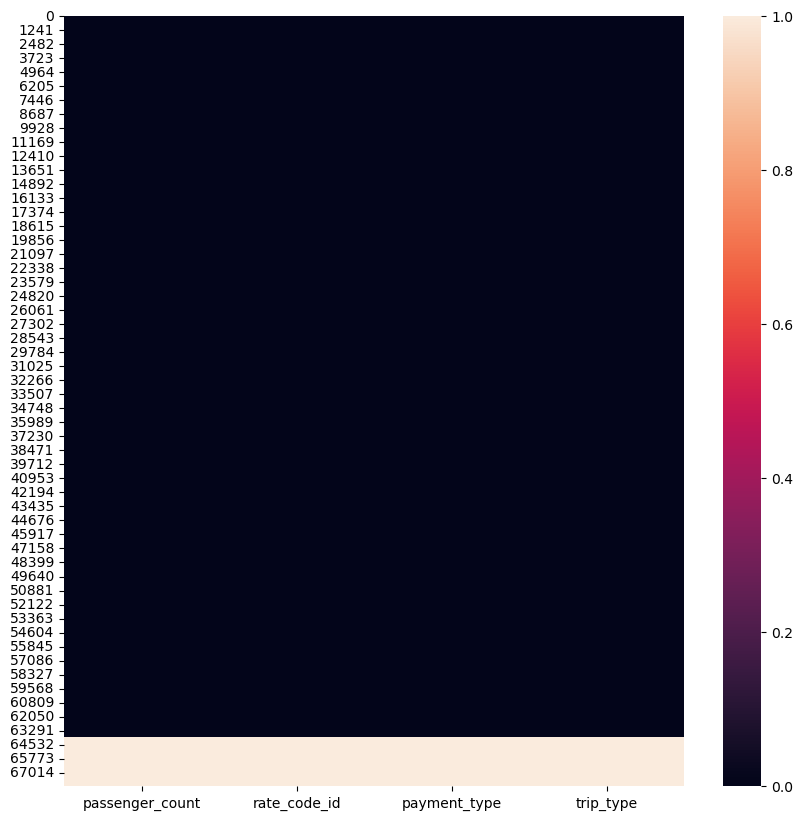

In [31]:
# Sebaran missing value di dalam data
plt.figure(figsize=(10,10))
sns.heatmap(df[['passenger_count', 'rate_code_id', 'payment_type', 'trip_type']].isna())

**interpretasi :**   
dari grafik tersebut sebenarnya sudah ketahuan, missing value dari keempat kolom ini identik, maksudnya missing value di baris yang sama. dimulai dari index 63887 sampai 68210. artinya terdapat total 4324 rows data missing

In [32]:
df.loc[df['trip_type'].isnull()]

,vendor_id,pickup_datetime,dropoff_datetime,rate_code_id,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_type
1084,1,2023-01-01 19:44:13,2023-01-01 19:58:30,99.0,150,55,1.0,3.30,18.20,0.00,19.70,1.0,NaN
2174,1,2023-01-02 16:39:05,2023-01-02 17:31:42,99.0,73,82,1.0,3.70,23.50,0.00,25.00,1.0,NaN
9055,1,2023-01-05 20:33:45,2023-01-05 22:46:41,99.0,14,123,1.0,6.20,28.20,0.00,29.70,1.0,NaN
14125,1,2023-01-08 11:36:41,2023-01-08 12:14:59,99.0,61,77,1.0,2.70,22.50,0.00,24.00,1.0,NaN
29143,1,2023-01-15 13:51:42,2023-01-15 14:37:38,99.0,108,181,1.0,6.50,24.20,0.00,25.70,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,49,62,NaN,4070.82,15.70,0.00,16.70,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,10,205,NaN,2.14,4.41,0.00,5.41,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,66,37,NaN,3.44,16.53,3.51,21.04,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,225,189,NaN,3.03,14.98,3.20,19.18,NaN,NaN


In [33]:
df.loc[df['passenger_count'].isnull(), ['passenger_count', 'rate_code_id', 'payment_type', 'trip_type']]

,passenger_count,rate_code_id,payment_type,trip_type
63887,NaN,NaN,NaN,NaN
63888,NaN,NaN,NaN,NaN
63889,NaN,NaN,NaN,NaN
63890,NaN,NaN,NaN,NaN
63891,NaN,NaN,NaN,NaN
...,...,...,...,...
68206,NaN,NaN,NaN,NaN
68207,NaN,NaN,NaN,NaN
68208,NaN,NaN,NaN,NaN
68209,NaN,NaN,NaN,NaN


In [34]:
df[['passenger_count', 'rate_code_id', 'payment_type', 'trip_type']].isnull().value_counts()

passenger_count  rate_code_id  payment_type  trip_type
False            False         False         False        63877
True             True          True          True         4324 
False            False         False         True         10   
Name: count, dtype: int64

**interpretasi :**   
output ini juga mengkonfirmasi hal serupa yang diatas, terdapat 4324 rows misisng value yang sejajar, ditambah 10 value missing di kolom `trip_type`

In [35]:
df[df["rate_code_id"] == 99]

,vendor_id,pickup_datetime,dropoff_datetime,rate_code_id,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_type
1084,1,2023-01-01 19:44:13,2023-01-01 19:58:30,99.0,150,55,1.0,3.3,18.2,0.0,19.7,1.0,NaN
2174,1,2023-01-02 16:39:05,2023-01-02 17:31:42,99.0,73,82,1.0,3.7,23.5,0.0,25.0,1.0,NaN
9055,1,2023-01-05 20:33:45,2023-01-05 22:46:41,99.0,14,123,1.0,6.2,28.2,0.0,29.7,1.0,NaN
14125,1,2023-01-08 11:36:41,2023-01-08 12:14:59,99.0,61,77,1.0,2.7,22.5,0.0,24.0,1.0,NaN
29143,1,2023-01-15 13:51:42,2023-01-15 14:37:38,99.0,108,181,1.0,6.5,24.2,0.0,25.7,1.0,NaN
29711,1,2023-01-15 17:52:52,2023-01-15 22:11:55,99.0,150,123,1.0,1.6,15.2,0.0,16.7,1.0,NaN
35975,1,2023-01-19 01:07:59,2023-01-19 01:17:19,99.0,90,68,1.0,0.6,15.2,0.0,16.7,1.0,NaN
37691,1,2023-01-19 17:16:59,2023-01-19 22:29:53,99.0,265,123,1.0,14.6,40.2,0.0,41.7,1.0,NaN
42432,1,2023-01-21 20:29:58,2023-01-22 02:59:25,99.0,150,123,1.0,1.4,15.2,0.0,16.7,1.0,NaN
45204,1,2023-01-23 13:45:11,2023-01-23 23:36:42,99.0,244,248,1.0,28.3,50.2,0.0,51.7,1.0,NaN


In [36]:
# drop karena missing di baris yang sama berurutan 
df.dropna(subset=['passenger_count', 'rate_code_id', 'payment_type', 'trip_type'], inplace=True)

In [37]:
print(f"setelah drop missing values: {df.shape[0]} rows")
print(f"sebelum drop missing values: {df_asli.shape[0]} rows")

setelah drop missing values: 63877 rows
sebelum drop missing values: 68211 rows


**interpretasi :**   
jumlah baris :   
* Setelah drop missing values: 63877 rows  
* sebelum drop missing values: 68211 rows  

In [38]:
df['passenger_count'] = df['passenger_count'].astype('int64')

seperti yang sudah direncanakan tadi, setelah dilakukan penghapusan mssing value dari kolom `passenger_count`, maka akan diubah tipe datanya 

In [39]:
df['passenger_count'].dtypes

dtype('int64')

sama dengan halnya passanger_count, kolom trip_type, payment_type, dan rate_code_id. karena tujuannya menghilangkan koma dibelakang, walaupun bisa juga pakai replace.

namun saya pakai cara ubah data lagi ke int setelah di bersihkan nilai nulnya, lalu ubah ke lagi ke type data object 

In [40]:
# ubah ke int, supaya komanya hilang dulu baru ke objt
df['trip_type']= df['trip_type'].astype('int')
df['payment_type'] = df['payment_type'].astype('int')
df['rate_code_id'] = df['rate_code_id'].astype('int')

df['trip_type']= df['trip_type'].astype('object')
df['payment_type'] = df['payment_type'].astype('object')
df['rate_code_id'] = df['rate_code_id'].astype('object')


### **Merge data zones** 

Setelah data NYC taxi sudah dibersihkan, maka disini saya akan menggabungkan nya dengan data frame taxi_zone_lookup.csv, sehingga akan ada penambahan kolom baru untuk nama lokasi dropoff maupun pickup.   
`pickup_boroug`  `pickup_zone`	 
`dropoff_borough`  	 
`dropoff_zone`    


selain itu, dikarenakan ada beberapa keterangan mengakibatkan datanya menjadi missing value, saya melakukan cleaning dan mapping lagi untuk penanganan masalah tersebut 
untuk kode 
* kode 264 artinya : "Unknown","N/A","N/A" --------------> akan saya keep dan buat menjadi "unknown"
* kode 265 artinya : "N/A","Outside of NYC","N/A --------------> akan saya buang karena, saya akan menganalisis berdasarakan yang ada di newyork city saja

In [41]:
df_zone_pickup = df_zone_asli.rename(columns={ 
                                    'LocationID':'pickup_location_id',
                                    'Borough':'pickup_borough',
                                    'Zone':'pickup_zone'})

In [42]:
df_zone_drop = df_zone_asli.rename(columns={ 
                                    'LocationID': 'dropoff_location_id',
                                    'Borough':'dropoff_borough',
                                    'Zone': 'dropoff_zone' })

In [43]:
df = df.merge(df_zone_pickup, on='pickup_location_id', how='left')

In [44]:
df = df.merge(df_zone_drop, on='dropoff_location_id', how='left') 

In [45]:
df

,vendor_id,pickup_datetime,dropoff_datetime,rate_code_id,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_type,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,1,166,143,1,2.58,14.9,4.03,24.18,1,1,Manhattan,Morningside Heights,Manhattan,Lincoln Square West
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,1,24,43,1,1.81,10.7,2.64,15.84,1,1,Manhattan,Bloomingdale,Manhattan,Central Park
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,1,223,179,1,0.00,7.2,1.94,11.64,1,1,Queens,Steinway,Queens,Old Astoria
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,1,41,238,1,1.30,6.5,1.70,10.20,1,1,Manhattan,Central Harlem,Manhattan,Upper West Side North
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,1,41,74,1,1.10,6.0,0.00,8.00,1,1,Manhattan,Central Harlem,Manhattan,East Harlem North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63872,2,2023-01-31 23:09:22,2023-01-31 23:17:21,5,130,205,1,2.75,15.0,2.00,17.30,1,2,Queens,Jamaica,Queens,Saint Albans
63873,2,2023-01-31 23:06:18,2023-01-31 23:17:03,1,65,181,1,2.44,13.5,3.20,19.20,1,1,Brooklyn,Downtown Brooklyn/MetroTech,Brooklyn,Park Slope
63874,2,2023-01-31 23:17:03,2023-01-31 23:23:04,1,244,116,1,1.40,9.3,2.36,14.16,1,1,Manhattan,Washington Heights South,Manhattan,Hamilton Heights
63875,2,2023-01-31 23:29:18,2023-01-31 23:38:50,1,74,238,1,2.47,13.5,3.75,22.50,1,1,Manhattan,East Harlem North,Manhattan,Upper West Side North


In [46]:
df.isnull().sum()

vendor_id              0  
pickup_datetime        0  
dropoff_datetime       0  
rate_code_id           0  
pickup_location_id     0  
dropoff_location_id    0  
passenger_count        0  
trip_distance          0  
fare_amount            0  
tip_amount             0  
total_amount           0  
payment_type           0  
trip_type              0  
pickup_borough         65 
pickup_zone            135
dropoff_borough        224
dropoff_zone           424
dtype: int64

In [47]:
df.loc[df['dropoff_zone'].isnull(), ['dropoff_location_id']].value_counts()

dropoff_location_id
264                    424
Name: count, dtype: int64

In [48]:
df.loc[df['dropoff_borough'].isnull(), ['dropoff_location_id']].value_counts()

dropoff_location_id
265                    224
Name: count, dtype: int64

In [49]:
df.loc[df['pickup_borough'].isnull(), ['pickup_location_id']].value_counts()

pickup_location_id
265                   65
Name: count, dtype: int64

In [50]:
df.loc[df['pickup_zone'].isnull(), ['pickup_location_id']].value_counts()

pickup_location_id
264                   135
Name: count, dtype: int64

berdasarakan file taxi_zone_lookup.csv, 

* kode 264 artinya : "Unknown","N/A","N/A"
* kode 265 artinya : "N/A","Outside of NYC","N/A

In [51]:
# iisi id 264 dengan "Unknown"
df['pickup_borough'] = df['pickup_borough'].fillna('Unknown')
df['pickup_zone']    = df['pickup_zone'].fillna('Unknown')
df['dropoff_borough'] = df['dropoff_borough'].fillna('Unknown')
df['dropoff_zone']    = df['dropoff_zone'].fillna('Unknown')

### **Filter data**

Filter data meliputi :   
* hanya ambil `pickup_datetime.dt.year == 2023`  
* `trip_distance`: hanya ambil 0 < jarak <= 50 miles  
    * Jarak 0 = tidak ada perjalanan, >50 miles alias 80 km = tidak mungkin untuk taksi dalam kota NYC  
* `fare_amount` , `total_amount` > 0  
    * Tarif tidak mungkin negatif atau 0... tapi pengecualian untuk kondisi `payment_type` nya 3 dan 4 
    * karena `payment_type` = 3 artinya Nocharge, artinya memang terccatat gratis 
    * dan `payment_type` = 4 dispute
* `tip_amount` >= 0
    * Tip bisa 0, tapi tidak negatif
* `passenger_count` >= 1
    * Tidak mungkin ada trip tanpa penumpang
* `rate_code_id` != 99.0  
    * Kode 99 tidak ada di data dictionary NYC TLC, anomali 
* hapus baris yang tripnya di luar NYC kodenya != 265



In [52]:
# hapus baris yang tripnya di luar NYC
df = df[df['pickup_location_id'] != 265]
df = df[df['dropoff_location_id'] != 265]

In [53]:
df.isnull().sum()

vendor_id              0
pickup_datetime        0
dropoff_datetime       0
rate_code_id           0
pickup_location_id     0
dropoff_location_id    0
passenger_count        0
trip_distance          0
fare_amount            0
tip_amount             0
total_amount           0
payment_type           0
trip_type              0
pickup_borough         0
pickup_zone            0
dropoff_borough        0
dropoff_zone           0
dtype: int64

In [54]:
# data tahun 2023 aja
df =df[df['pickup_datetime'].dt.year == 2023]

In [55]:
print(df_asli[(df_asli['trip_distance']>0) & (df_asli['trip_distance'] >= 62)].count())
print(df_asli[(df_asli['trip_distance']<0)].count()) 
print(df_asli[(df_asli['trip_distance']>0) & (df_asli['trip_distance'] >= 62) & (df_asli['PULocationID'].isin([265,266]))].count()) 
# ingin konfirmasi dan mencari apakah ada perjalanannya jauh, ke luar kota. namun hasilnya gaada, brrti filter menghilangkan data 265, aman jaya

VendorID                 38
lpep_pickup_datetime     38
lpep_dropoff_datetime    38
store_and_fwd_flag       2 
RatecodeID               2 
PULocationID             38
DOLocationID             38
passenger_count          2 
trip_distance            38
fare_amount              38
extra                    38
mta_tax                  38
tip_amount               38
tolls_amount             38
ehail_fee                0 
improvement_surcharge    38
total_amount             38
payment_type             2 
trip_type                2 
congestion_surcharge     2 
dtype: int64
VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
store_and_fwd_flag       0
RatecodeID               0
PULocationID             0
DOLocationID             0
passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
ehail_fee                0
improvement_surcharge 

berdasarakn hasil riset melalui internet :

Jarak Tempuh: Jarak terjauh di dalam NYC—dari timur laut ke barat daya—adalah sekitar 35 mil (sekitar 56 km)
namun saya menggenapkan angkanya menjadi kisaran 50 miles

In [56]:
# ambil data trip distance yang lebih besar dari 0. karna klo 0, brrti ga kemana2 dung
# ambil data trip distance yang lebih kecil dari 50 miles ----->  karna tidak mungkin, dengan luas newyork
df = df[(df['trip_distance']>0) & (df['trip_distance'] <= 50)]

In [57]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone'],
      dtype='object')

In [58]:
df_asli[(df_asli['payment_type'].isin([3.0,4.0])) &(df_asli['fare_amount'] == 0.0)]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
13889,1,2023-01-08 05:14:25,2023-01-08 05:14:50,N,5.0,129,129,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3.0,2.0,0.0
28612,1,2023-01-15 02:44:28,2023-01-15 02:44:45,N,5.0,92,92,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3.0,2.0,0.0
40820,1,2023-01-21 03:36:32,2023-01-21 03:37:20,N,5.0,265,265,1.0,28.8,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,4.0,2.0,0.0
51901,1,2023-01-26 10:50:42,2023-01-26 10:51:30,N,5.0,41,75,2.0,0.1,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3.0,2.0,0.0


dikarenakan kolom `payment_type` = 3 dan 4, itu adalah Nocharge dan Dispute. maka dengan kondisi tersebut masih diperbolehkan jika kolom `fare_amount` dan `total_amount` bernilai 0 

In [59]:
# ambil data fare_amount, total_amount, yang lebih besar dari 0. karna klo 0, artinya mereka gratis. tapi klo payment type 3 atau 4, boleh 0
df = df[((df['fare_amount'] > 0) &(df['total_amount'] > 0)) | ((df['fare_amount'] == 0) &(df['payment_type'].isin([3, 4])))]

# kode ini ngefilter data yang memenuhi salah satu dari dua kondisi:
# 1. Data dengan fare_amount lebih besar dari 0 dan total_amount lebih besar dari 0, atau
# 2. Data dengan fare_amount sama dengan 0 dan payment_type termasuk dalam daftar [3, 4].

In [60]:
# filter tip_amount 
df = df[df['tip_amount'] >= 0]

In [61]:
# ambil data fare_amount, total_amount, tip_amount yang lebih besar dari 1. karna klo 0, brrti cargonya tidak ada orang. mungkin bisa barang. tapi saya filter aja

df = df[df['passenger_count'] >= 1]

In [62]:
# dikarenakan pada tahap sebelumnya, 99 tidak ada keterangan di dictionary nya, sehingga termasuk anomali 
df = df[df['rate_code_id'] != 99.0]

### **Membuat Kolom baru** 

membuat kolom baru untuk melihat pola waktu, dikarenakan kita sudah memfilter data berdsarkn jarak tempuh dan akan juga memfilter berdsarkan waktu tempuh max 3 jam, pastinya kemungkinan besar pickupdate sama droppoff date terjadi di hari yang sama. selain itu karna kita mau menjawab pertanyaan analysis demand juga, maka cukup perlu mengextrak kolom dari pickupdatetime aja

kolom yang di buat yaitu :  
`durasi_waktu` = total Durasi penumpang  
`pickup_hour` = informasi jam jemputan   
`pickup_day_of_week` = informasi hari per minggu    
`pickup_day_name` = informasi nama hari    
`pickup_month` = informasi nama bulan    
`pickup_date` = informasi tanggal  
`shift_waktu` = pembagian waktu dalam sehari    

In [63]:
df['durasi_waktu']= (df['dropoff_datetime']-df['pickup_datetime']).dt.total_seconds()/60

setelah melakukan riset bahwa 

Waktu Terlama saat Jam Sibuk (Rush Hour): Perjalanan yang biasanya 30-45 menit bisa membengkak menjadi 1,5 hingga 3 jam atau lebih saat macet total (misalnya pukul 4 sore)

In [64]:
# Filter durasi yang tidak masuk akal trip 0 menit yang ga valid dan trip yang lebih dari 3 jam di kota
df =df[(df['durasi_waktu']>0)&(df['durasi_waktu'] <=180)].round(2)

In [65]:
# pecah watu pickup_datetime supaya bisa dianalisis per jam, hari, bulan
df['pickup_hour']= df['pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek 
df['pickup_day_name'] = df['pickup_datetime'].dt.day_name()
df['pickup_month'] =df['pickup_datetime'].dt.month
df['pickup_date']=df['pickup_datetime'].dt.date

In [66]:
df

,vendor_id,pickup_datetime,dropoff_datetime,rate_code_id,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,...,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,durasi_waktu,pickup_hour,pickup_day_of_week,pickup_day_name,pickup_month,pickup_date
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,1,166,143,1,2.58,14.9,4.03,...,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,11.02,0,6,Sunday,1,2023-01-01
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,1,24,43,1,1.81,10.7,2.64,...,Manhattan,Bloomingdale,Manhattan,Central Park,6.77,0,6,Sunday,1,2023-01-01
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,1,41,238,1,1.30,6.5,1.70,...,Manhattan,Central Harlem,Manhattan,Upper West Side North,5.82,0,6,Sunday,1,2023-01-01
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,1,41,74,1,1.10,6.0,0.00,...,Manhattan,Central Harlem,Manhattan,East Harlem North,5.97,0,6,Sunday,1,2023-01-01
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,1,41,262,1,2.78,17.7,0.00,...,Manhattan,Central Harlem,Manhattan,Yorkville East,17.55,0,6,Sunday,1,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63872,2,2023-01-31 23:09:22,2023-01-31 23:17:21,5,130,205,1,2.75,15.0,2.00,...,Queens,Jamaica,Queens,Saint Albans,7.98,23,1,Tuesday,1,2023-01-31
63873,2,2023-01-31 23:06:18,2023-01-31 23:17:03,1,65,181,1,2.44,13.5,3.20,...,Brooklyn,Downtown Brooklyn/MetroTech,Brooklyn,Park Slope,10.75,23,1,Tuesday,1,2023-01-31
63874,2,2023-01-31 23:17:03,2023-01-31 23:23:04,1,244,116,1,1.40,9.3,2.36,...,Manhattan,Washington Heights South,Manhattan,Hamilton Heights,6.02,23,1,Tuesday,1,2023-01-31
63875,2,2023-01-31 23:29:18,2023-01-31 23:38:50,1,74,238,1,2.47,13.5,3.75,...,Manhattan,East Harlem North,Manhattan,Upper West Side North,9.53,23,1,Tuesday,1,2023-01-31


In [67]:
# buat pembagian hari weekday dengan weekend
df['is_weekend'] = df['pickup_day_of_week'].apply(lambda x:1 if x>= 5 else 0)
df['tipe_hari']= df['is_weekend'].map({0:'Weekday',1:'Weekend'})

shift waktu perlu sumber ini 

In [68]:
def kategori_waktu(hour):
    if 0 <=hour<6:
        return 'Dini Hari (00-05)'
    elif 6<=hour < 10:
        return 'Pagi (06-10)'
    elif 10<=hour< 15:
        return 'Siang (10-15)'
    elif 15 <= hour<19:
        return 'Sore (15-19)'
    else:
        return 'Malam (19-24)'

df['shift_waktu'] = df['pickup_hour'].apply(kategori_waktu)

In [69]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone', 'durasi_waktu', 'pickup_hour',
       'pickup_day_of_week', 'pickup_day_name', 'pickup_month', 'pickup_date',
       'is_weekend', 'tipe_hari', 'shift_waktu'],
      dtype='object')

## **4. Cek Kualitas Data**

In [70]:
kolom_numerik = ['trip_distance', 'fare_amount', 'tip_amount', 
            'total_amount', 'passenger_count', 'durasi_waktu']

### **Deskriptif**

In [71]:
df[kolom_numerik].describe().round(2)

,trip_distance,fare_amount,tip_amount,total_amount,passenger_count,durasi_waktu
count,59812.00,59812.00,59812.00,59812.00,59812.00,59812.00
mean,2.64,15.73,2.10,20.97,1.33,13.24
std,2.49,11.21,2.93,13.34,0.99,9.37
min,0.01,0.00,0.00,0.00,1.00,0.02
25%,1.20,9.30,0.00,12.66,1.00,7.23
50%,1.88,12.80,1.66,17.46,1.00,11.10
75%,3.14,18.40,3.28,25.20,1.00,16.57
max,41.74,455.00,222.22,456.00,8.00,172.48


setelah dilakukan pembersihan data, berdasarkan tabel output ini bisa dlihat bahwa datanya sudah steril bersihh. 
Sudah nggak ada lagi value yang nggak masuk akal, kayak tagihan argo yang minus atau taksi yang jalan tanpa penumpang.  
Karena data anomali, missing value, dan lainnya sudah berhasil kita cleaning dan filter, 


**Data awal =  68.211 rows**  
**Data Bersih Final =  59.811 rows**  


sehingga datanya sudah aman untuki kita lanjutkan ke bagian selanutnya mendekati tahap analisis

### **Distribusi**

melakukan pengecekan distribusi data dengan kolmogrof dikarenakan kita memiliki jumlah yang banyak lebih dari 5000 baris   
disini dilakukan pengecekan distribusi untuk mengetahui data kita normal atau tidak, sehingga dpat menentukan uji statistik yang akan kita pakai selanjutnya

* Kalau normal uji parametrik
* Kalau tidak normal uji non-parametrik (manwhitney, wilcoxon, kruskal)

berdasarkan dibawah ini kesimpulan poin besarnya ternyata semua kolom yng di uji tidak normal

In [72]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone', 'durasi_waktu', 'pickup_hour',
       'pickup_day_of_week', 'pickup_day_name', 'pickup_month', 'pickup_date',
       'is_weekend', 'tipe_hari', 'shift_waktu'],
      dtype='object')

In [73]:
print(df['payment_type'].unique())
print(df['trip_type'].unique())
print(df['tipe_hari'].unique())
print(df['shift_waktu'].unique())

[1 2 3 4]
[1 2]
['Weekend' 'Weekday']
['Dini Hari (00-05)' 'Pagi (06-10)' 'Siang (10-15)' 'Sore (15-19)'
 'Malam (19-24)']


In [74]:
# cek distribusi untuk tiap kolom numerik  
for col in kolom_numerik:
    statistic,p_value = stats.kstest(df[col],'norm')
    skew = df[col].skew()
    print(f"{col} | p={p_value} | skewness={round(skew,2)} | Data {'Tidak Normal' if p_value<0.05 else 'Normal'}")

trip_distance | p=0.0 | skewness=3.19 | Data Tidak Normal
fare_amount | p=0.0 | skewness=5.87 | Data Tidak Normal
tip_amount | p=0.0 | skewness=11.43 | Data Tidak Normal
total_amount | p=0.0 | skewness=4.37 | Data Tidak Normal
passenger_count | p=0.0 | skewness=3.46 | Data Tidak Normal
durasi_waktu | p=0.0 | skewness=2.85 | Data Tidak Normal


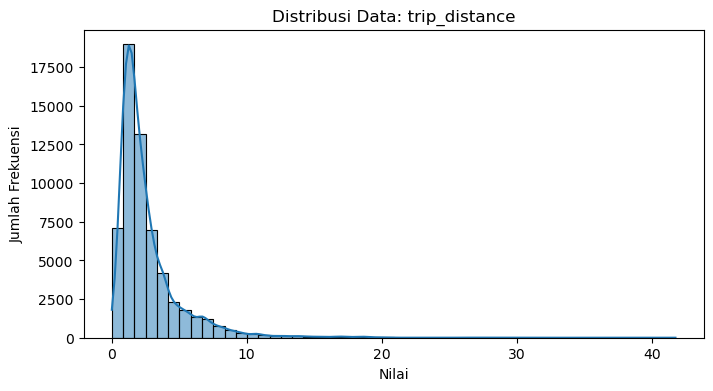

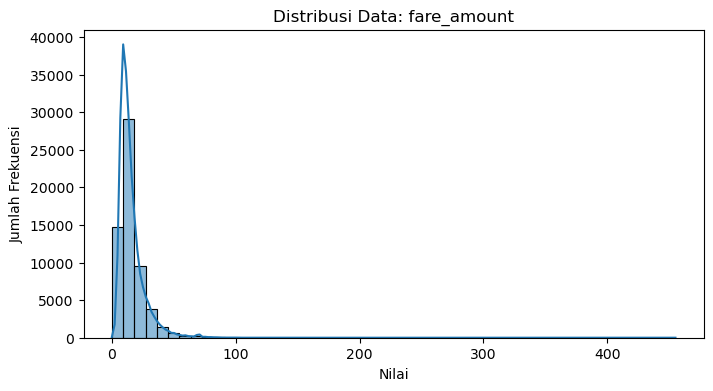

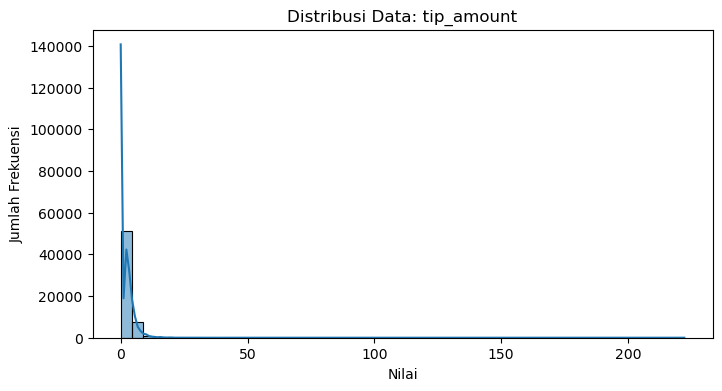

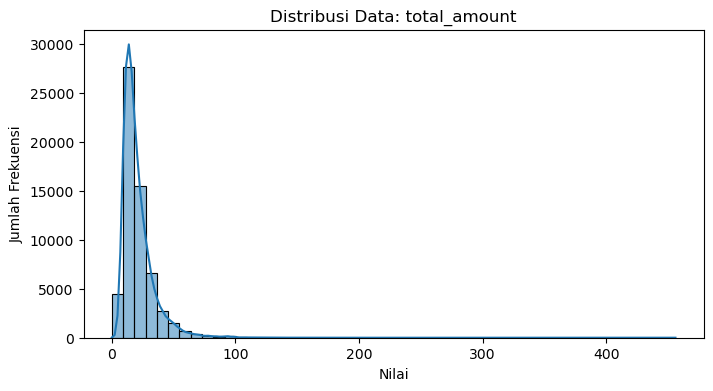

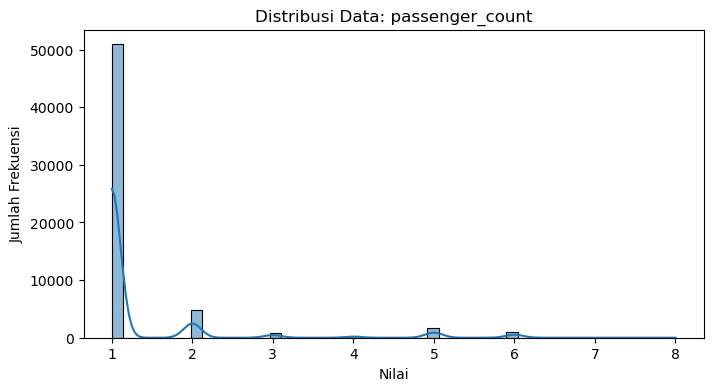

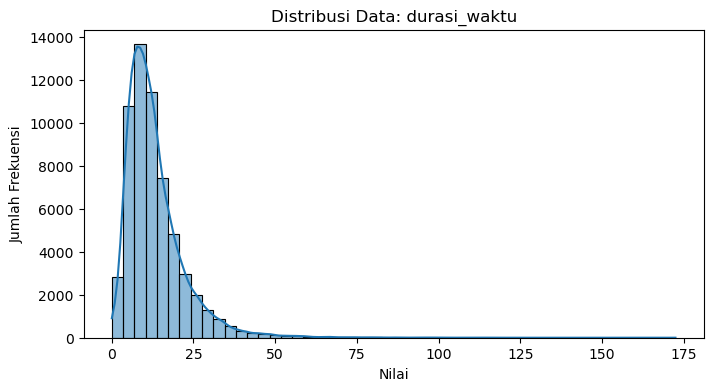

In [75]:
for col in kolom_numerik:
    plt.figure(figsize=(8, 4)) 
    sns.histplot(data=df, x=col,bins=50,kde=True)
    plt.title(f'Distribusi Data: {col}', fontsize=12)
    plt.xlabel('Nilai')
    plt.ylabel('Jumlah Frekuensi')
    plt.show()

**interpretasi:** 

semua kolom tidak normal (p < 0.05, skewness tinggi), semua skewness ke kanan

Jadi analisis selanjutnya pakai **uji non-parametrik**.

### **Outlier**

In [76]:
for col in kolom_numerik:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR= Q3 - Q1
    lower= Q1-1.5*IQR
    upper= Q3+1.5 *IQR
    outlier =len(df[(df[col] <lower) | (df[col] >upper)])
    pct= outlier/len(df) * 100
    print(f"{col}: {outlier} ({round(pct,2)}%)")

trip_distance: 4936 (8.25%)
fare_amount: 4084 (6.83%)
tip_amount: 1662 (2.78%)
total_amount: 3278 (5.48%)
passenger_count: 8905 (14.89%)
durasi_waktu: 2807 (4.69%)


outlier ini tidak  dhapus. karena ini data bisnis ya dan faktanya memang seperti ini. sbnrnya semua kolom numerik yang kita cek semua berkaitan satu sama lain,    
misal dari klom `trip_distance` banyaknya taksi dengan jarak tempuh mayoritas pergi jarak dekat. jarang banget tuh orang yang mungkin pergi jauh2 pake taksi.   
terjadi hal yang sama pada lainnya,   
intinya dikarenakan kita juga sudah cek distribusi data yang semuanya miring ke kanan, jadi titik tengahnya juga ada di kanan,   
dan banyak deh outlier data yang besar2  

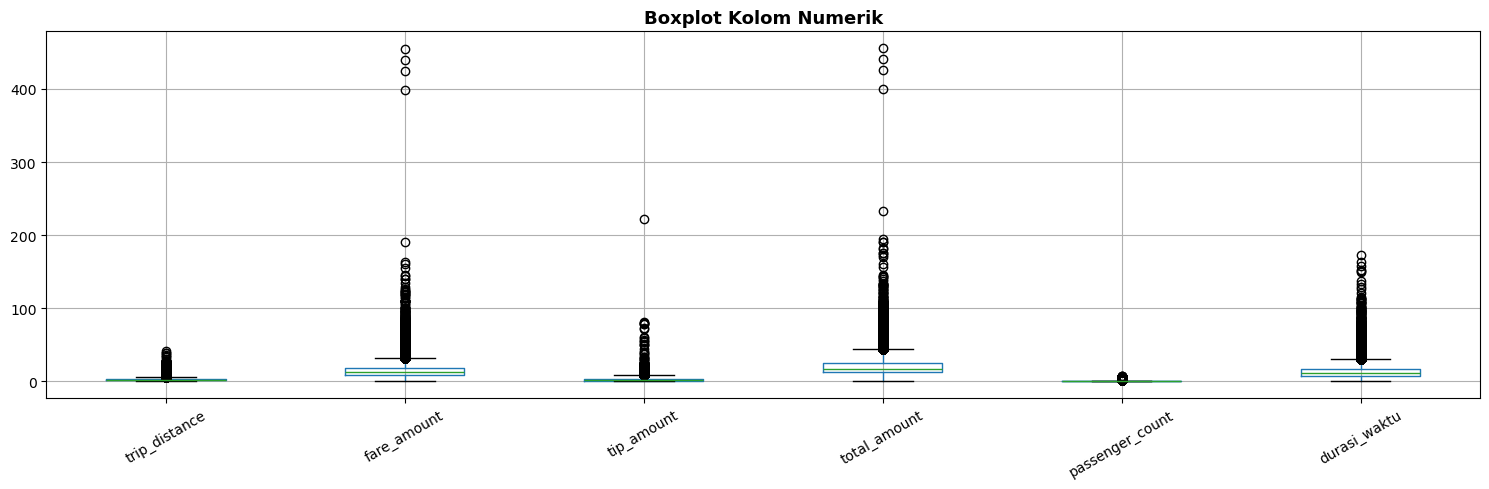

In [77]:
df.boxplot(column=kolom_numerik, figsize=(15, 5))
plt.title('Boxplot Kolom Numerik', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [78]:
df.to_csv('NYC_Taxi_Cleaned_CP2.csv',index=False)

In [79]:
df.dtypes

vendor_id              object        
pickup_datetime        datetime64[ns]
dropoff_datetime       datetime64[ns]
rate_code_id           object        
pickup_location_id     int64         
dropoff_location_id    int64         
passenger_count        int64         
trip_distance          float64       
fare_amount            float64       
tip_amount             float64       
total_amount           float64       
payment_type           object        
trip_type              object        
pickup_borough         object        
pickup_zone            object        
dropoff_borough        object        
dropoff_zone           object        
durasi_waktu           float64       
pickup_hour            int32         
pickup_day_of_week     int32         
pickup_day_name        object        
pickup_month           int32         
pickup_date            object        
is_weekend             int64         
tipe_hari              object        
shift_waktu            object        
dtype: objec

## **5. Analysis**


pada bagian analisi ini, kita akan jawab pertanyaan utamanya:

**Bagaimana pola permintaan layanan Taxi di NYC berdasarkan waktu, lokasi, perilaku penumpang? serta insight apa yang dapat membantu distribusi armada serta strategi operasional yang lebih baik?**

Dibagi jadi beberapa pertanyaan:
1. saat kapan demand paling tinggi? (berdsaarkan jam, hari, dan shift_waktu )
2. di mana demand paling tinggi? (berdasarkan borough/wilayah dan zona)
3. jam berapa dan di mana demand tertinggi?
4. apakah ada perbedaan demand penumpang di weekday vs weekend?
5. bagaimana perilaku penumpang?

In [80]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone', 'durasi_waktu', 'pickup_hour',
       'pickup_day_of_week', 'pickup_day_name', 'pickup_month', 'pickup_date',
       'is_weekend', 'tipe_hari', 'shift_waktu'],
      dtype='object')

### 1. Kapan demand paling tinggi? (berdsaarkan jam, hari, dan shift_waktu)

#### berdasarkan jam

In [144]:
# total perjalanan per jam
trend_jam = df.groupby('pickup_hour').size().reset_index(name='total_trip')
trend_jam.set_index('pickup_hour')

,total_trip
pickup_hour,
0,951
1,752
2,526
3,479
4,348
5,332
6,814
7,2267
8,2725


In [82]:
jam_rame = trend_jam.loc[trend_jam['total_trip'].idxmax()]
jam_sepi = trend_jam.loc[trend_jam['total_trip'].idxmin()]
print(f"Jam paling ramai : pukul {(jam_rame['pickup_hour'])}:00 terdapat {(jam_rame['total_trip'])} perjalanan")
print(f"Jam paling sepi : pukul {(jam_sepi['pickup_hour'])}:00 terdapat {(jam_sepi['total_trip'])} perjalanan ")

Jam paling ramai : pukul 18:00 terdapat 4758 perjalanan
Jam paling sepi : pukul 5:00 terdapat 332 perjalanan 


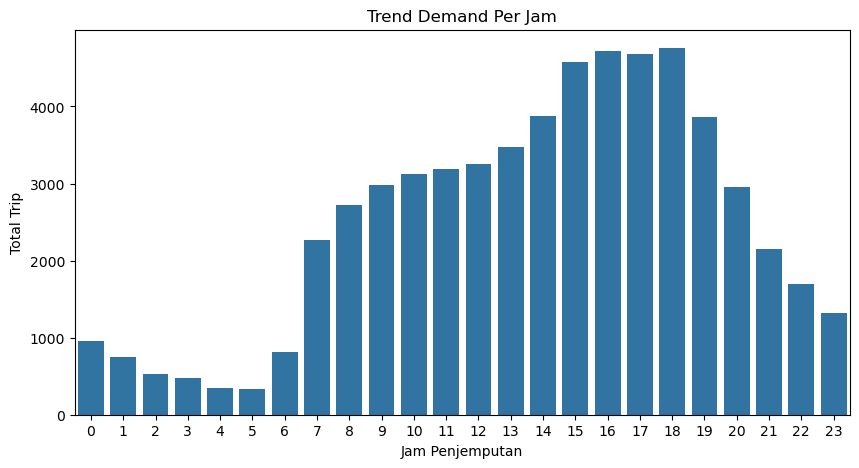

In [83]:
# bar chart per jam 
plt.figure(figsize=(10,5))
sns.barplot(data=trend_jam, x='pickup_hour', y='total_trip')
plt.title('Trend Demand Per Jam')
plt.xlabel('Jam Penjemputan')
plt.ylabel('Total Trip')
plt.show()

**Interpretasi:**
Berdsrkan yang diatas kita bisa mengetahui bahwa :
* Jam **18:00** jadi jam tersibuk, karena ada sekitar 4700 trip, atau hampir 8% dari total harian
* lalu demand juga mulai naik dari signifikan jam 15:00, sampai menyentuh tertinggi di jam 18:00
* Jam 05:00 menjadi jam paling sepi penumpang sekitar 330 trip, mungkin dikarenakan orang yang mayoritas masi istirahat
* untuk peningkatan penumpang dalam satu harii dimulai pada jam 7:00

**rekomendasi:** armada taxi harus selalu siap di jam 14:00-20:00. lalu untuk waktu dini hari bisa dikurangi untuk efisiensi

setelah mengetahui secara sekilas dengan melihat grafik, mari kita buktikan secara statistik apakah ada korelasi antara jam penjemputan dengan total perjalanan. kita akan menggunakan uji korelasi 
digunakan uji korelasi spearman karena data tidak normal berdsarkan hasil uji normalitas di tahap sebelumnya

In [84]:
# Korelasi Spearman
korelasi,p_corr= stats.spearmanr(trend_jam['pickup_hour'],trend_jam['total_trip'])
print(f"Nilai Korelasi: {korelasi}")
print(f"P-Value: {p_corr}")

Nilai Korelasi: 0.5791304347826086
P-Value: 0.00302338820095787


ternyata berdsarkan uji korelasi spearma, bisa kita lihat bahwa ada hubungan antara jam dan jumlah perjalanan atau bisa kita bialng demand penumpang

#### berdasarkan hari

setelah itu, kita akan menganlisis demand atau jumlah perjalanan berdasarkan hari, hari apa yang paling banyak kira2 ??

In [85]:
demand_hari = df.groupby('pickup_day_name').size().reset_index(name='jumlah_trip').sort_values(by='jumlah_trip', ascending=False)
demand_hari

,pickup_day_name,jumlah_trip
5,Tuesday,9927
4,Thursday,8942
1,Monday,8776
0,Friday,8753
6,Wednesday,8709
2,Saturday,7469
3,Sunday,7236


berdasarkan tabel di atas menunjukkan bahwa hari selasa yang menjadi hari tersibuk, dengan total perjalanan hampir menyentuh 10000

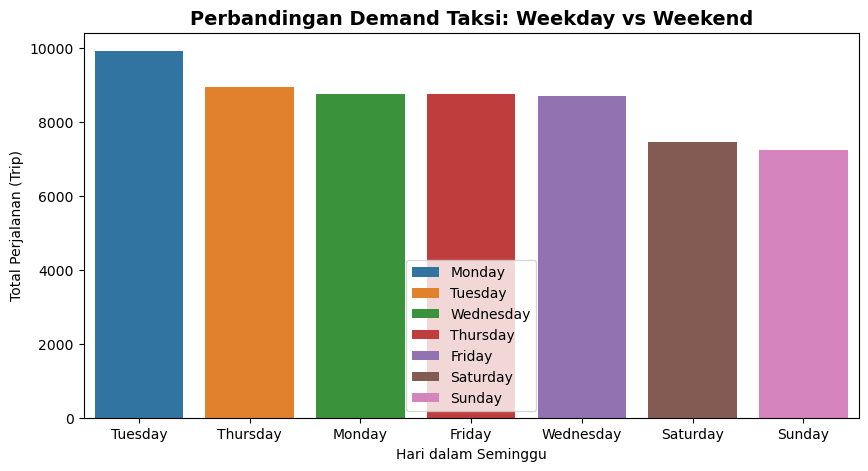

In [86]:
hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'] # atau b indo aja ya 
df['pickup_day_name'] = pd.Categorical(df['pickup_day_name'], categories=hari, ordered=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=demand_hari, x='pickup_day_name', y='jumlah_trip', hue=hari)
plt.title('Perbandingan Demand Taksi: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Hari dalam Seminggu')
plt.ylabel('Total Perjalanan (Trip)')
plt.show()

**interpretasi:**  
* Weekday selalu lebih ramai dari weekend, 
* Selasa paling tinggi 9927 perjalanan 
* Minggu paling sepi 7236 perjalanan

dikarenakan pengguna taxi ternyata lebih banyak di pakai ketika hari kerja, mungkin penggunaan taxi lebih dominan digunakan untuk mobilitas para pekerja, sedangkan ketika hari libur, warga lokal lebih dominan untuk menggunakan kendaraan pribadi. jadi ini di dukung juga oleh data sebelumnya yang mana taxi meningkat di jam2 orang berangkat kerja dan pulang kerja

#### berdasarkan pembagian waktu dalam sehari

selanjutnya mari kita lihat juga berdasarkan pembagian waktu dalam sehari, walaupun mungkin sudah ketebak ya, paling rame di jam2 kerja

dalam data ini kita sudah mengkategorikan jam dalam sehari menjadi beberapa bagian 
1. Sore (15-19)         
2. Siang (10-15)        
3. Malam (19-24)      
4. Pagi (06-10)          
5. Dini Hari (00-05)

In [87]:
df['shift_waktu'].value_counts()

shift_waktu
Sore (15-19)         18735
Siang (10-15)        16906
Malam (19-24)        11996
Pagi (06-10)         8787 
Dini Hari (00-05)    3388 
Name: count, dtype: int64

In [88]:
urutan_shift =['Dini Hari (00-05)', 
                'Pagi (06-10)', 
                'Siang (10-15)',
                'Sore (15-19)', 
                'Malam (19-24)' ]
df['shift_waktu'] = pd.Categorical(df['shift_waktu'],categories=urutan_shift,ordered=True) # membuat ururtan shift waktu supaya pas di visualisasi ga acak acakan
demand_shift = df.groupby('shift_waktu').size().reset_index(name='jumlah_trip')

C:\Users\merah\AppData\Local\Temp\ipykernel_51528\2127715375.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_shift = df.groupby('shift_waktu').size().reset_index(name='jumlah_trip')


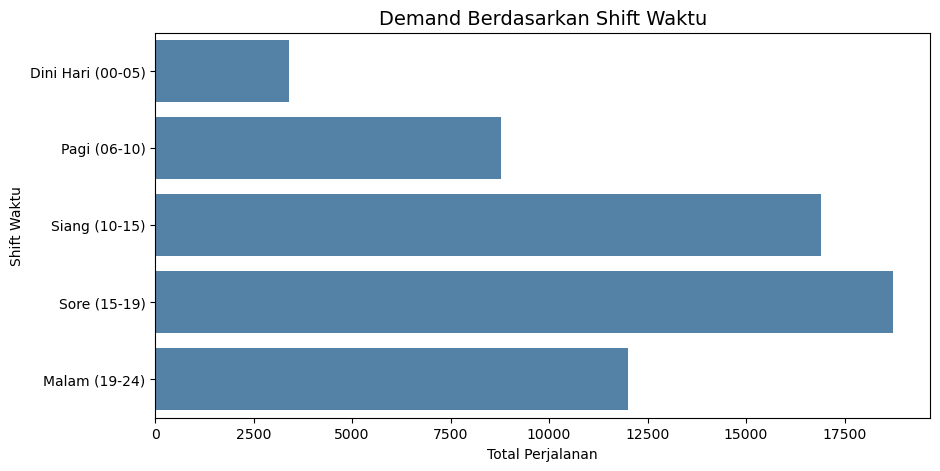

In [89]:
plt.figure(figsize=(10,5))
sns.barplot(data=demand_shift,y='shift_waktu',x='jumlah_trip',color='steelblue')
plt.title('Demand Berdasarkan Shift Waktu',fontsize=14)
plt.xlabel('Total Perjalanan')
plt.ylabel('Shift Waktu')
plt.show()

In [90]:
demand_shift

,shift_waktu,jumlah_trip
0,Dini Hari (00-05),3388
1,Pagi (06-10),8787
2,Siang (10-15),16906
3,Sore (15-19),18735
4,Malam (19-24),11996


**interpretasi:**  
* Shift Sore (15-19) paling ramai sebnyk 18735 perjalanan
* shift Siang (10-15) paling ramai kdua	16906 perjalanan, mungkin ini dikarenakan pada jam 14-15 yang mendekati jam pulang kantor

benar sekali ternyata visual diatas menunjukkan bahwa taxi digunakan oleh warga lokal untuk mobilitas kerja, dan ternyata jam berangkat kerja alias di pagi hari lumayan ada selisih jauh dengan jam pulang kerja di siang atau sore hari.

 mungkin jika dilihat secara visual, hasil datanya kelihatan bedany  
 oleh karena itu, agar pernyataannya lebih valid kita bisa uji pakai statistik

In [91]:
trip_shift = df.groupby(['pickup_date','shift_waktu']).size().reset_index(name='jumlah_trip')
trip_shift.head()

C:\Users\merah\AppData\Local\Temp\ipykernel_51528\3873109513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trip_shift = df.groupby(['pickup_date','shift_waktu']).size().reset_index(name='jumlah_trip')


,pickup_date,shift_waktu,jumlah_trip
0,2023-01-01,Dini Hari (00-05),263
1,2023-01-01,Pagi (06-10),85
2,2023-01-01,Siang (10-15),284
3,2023-01-01,Sore (15-19),312
4,2023-01-01,Malam (19-24),250


In [92]:
dini_hari = trip_shift[trip_shift['shift_waktu'] == 'Dini Hari (00-05)']['jumlah_trip']
pagi = trip_shift[trip_shift['shift_waktu'] == 'Pagi (06-10)']['jumlah_trip']
siang = trip_shift[trip_shift['shift_waktu'] == 'Siang (10-15)']['jumlah_trip']
sore = trip_shift[trip_shift['shift_waktu'] == 'Sore (15-19)']['jumlah_trip']
malam = trip_shift[trip_shift['shift_waktu'] == 'Malam (19-24)']['jumlah_trip']

In [93]:
# pake kruskal dikarenakan data tidak normal dan ada 5 kelompok waktu shift
stat_kw, p_kw =stats.kruskal(dini_hari, pagi, siang, sore, malam)
print(f"P-Value: {p_kw}")
if p_kw<0.05:
    print("tolak H0")
else:
    print("gagal tolak H0")

P-Value: 7.687932845160463e-23
tolak H0


berdsarkan hasil statistik, pola shift yang kita lihat di chart memang benar karena sudah terbukti secara statistik

### 2. Di mana demand paling tinggi?

Pertanyaan: Borough dan zona mana yang paling banyak demand atau tripnya?

In [94]:
df['pickup_borough'].unique()

array(['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island',
       'Unknown'], dtype=object)

In [95]:
lokasi = df['pickup_borough'].value_counts().reset_index()
lokasi

,pickup_borough,count
0,Manhattan,36436
1,Queens,15646
2,Brooklyn,7137
3,Bronx,558
4,Unknown,26
5,Staten Island,9


C:\Users\merah\AppData\Local\Temp\ipykernel_51528\417653929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lokasi[lokasi['pickup_borough'] !='Unknown'], x='pickup_borough',y='count',palette='Greens_r')


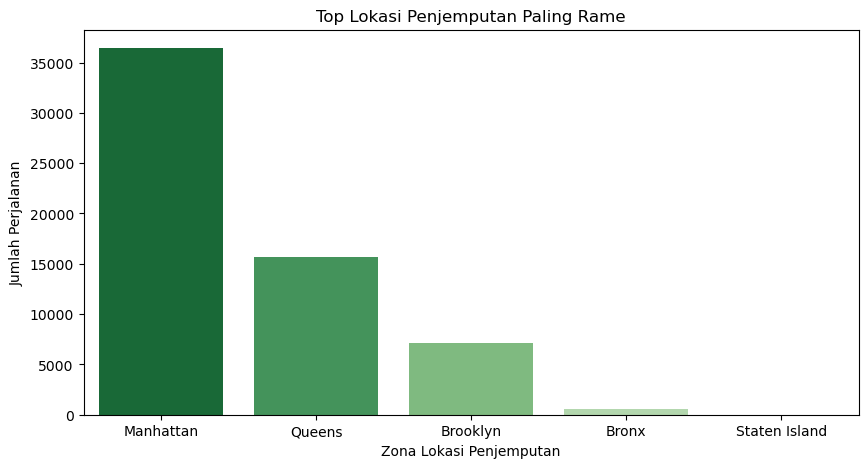

In [96]:
# bikin grafik
plt.figure(figsize=(10, 5))
sns.barplot(data=lokasi[lokasi['pickup_borough'] !='Unknown'], x='pickup_borough',y='count',palette='Greens_r')
plt.title('Top Lokasi Penjemputan Paling Rame')
plt.xlabel('Zona Lokasi Penjemputan')
plt.ylabel('Jumlah Perjalanan')
plt.show()

In [97]:
lokasi['persentase'] = (lokasi['count']/lokasi['count'].sum())*100
lokasi

,pickup_borough,count,persentase
0,Manhattan,36436,60.917542
1,Queens,15646,26.158630
2,Brooklyn,7137,11.932388
3,Bronx,558,0.932923
4,Unknown,26,0.043470
5,Staten Island,9,0.015047


In [145]:
lokasi.set_index('pickup_borough')

,count,persentase
pickup_borough,,
Manhattan,36436,60.917542
Queens,15646,26.158630
Brooklyn,7137,11.932388
Bronx,558,0.932923
Unknown,26,0.043470
Staten Island,9,0.015047


**Interpretasi:**
- Manhattan mendominasi 60.9%
- Queens 26.2%, Brooklyn 11.9%, Bronx hanya 0.9%

**Implikasi:** Bronx sangat rendah mungkin bisa potensi yang masih bisa di kembangkn

In [98]:
# hitung total trip per zona
trip_per_zona = df.groupby('pickup_zone').size().reset_index(name='jumlah_trip')
zona_top = trip_per_zona.sort_values(by='jumlah_trip', ascending=False)

In [151]:
# tampilkan semua baris zona top
zona_top.head(10).set_index('pickup_zone')

,jumlah_trip
pickup_zone,
East Harlem North,12635
East Harlem South,8584
Forest Hills,3641
Central Harlem,3612
Morningside Heights,3560
Central Park,2818
Elmhurst,2765
Fort Greene,2067
Astoria,1626


In [100]:
zona_top[['jumlah_trip']].agg(['sum','max','min','mean','median']).round(2)

,jumlah_trip
sum,59812.00
max,12635.00
min,1.00
mean,326.84
median,11.00


Total perjalanan paling banyak ada di East Harlem, totalnya jika di gabungkan 21200 an trip. yang mana hampir 30 persen dari semua total trip keseluruhan

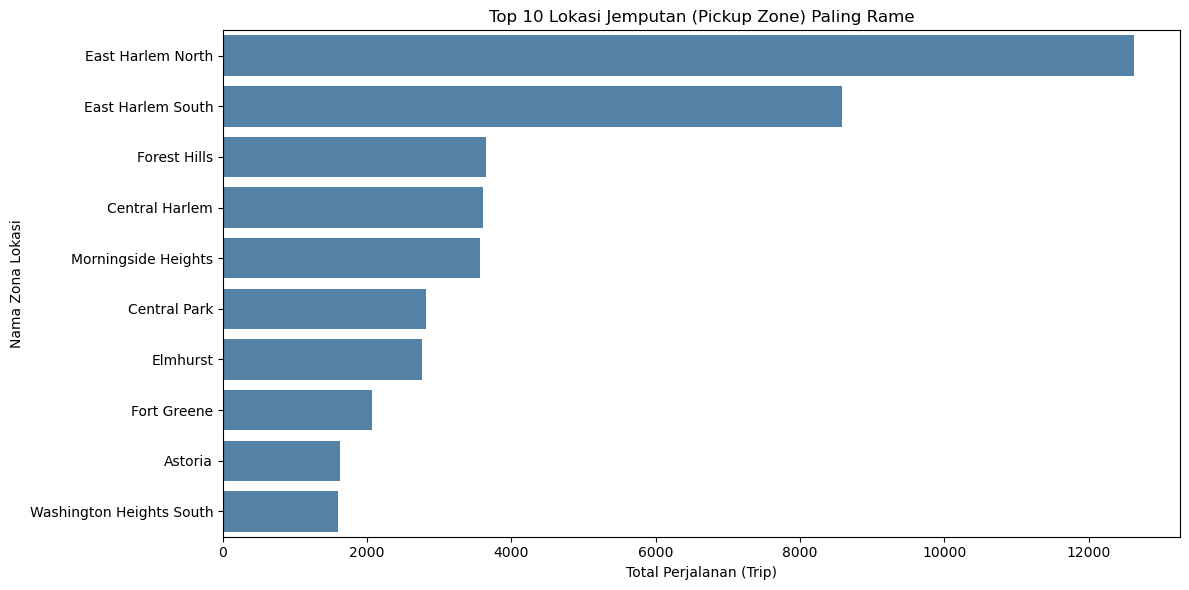

In [101]:
plt.figure(figsize=(12, 6))
sns.barplot(data=zona_top.head(10), y='pickup_zone', x='jumlah_trip', color='steelblue')
plt.title('Top 10 Lokasi Jemputan (Pickup Zone) Paling Rame')
plt.xlabel('Total Perjalanan (Trip)')
plt.ylabel('Nama Zona Lokasi')
plt.tight_layout()
plt.show()

**interpretasi:**

East Harlem North & South kisaran 35% dari total perjalanan yang ada atau sepertiga dari total perjalanan taxi di kota new york. karena mungkin area ini di Manhattan utara, Yellow Taxi jarang naik ke sini, jadi Green Taxi bisa memanfaatkan hal itu 

**Implikasi :**   
berikan fokus yang lebih pada east harlem, karena demand yang paling besar, sehingga resiko jika kehilangan pasar juga akan berdampak besar pada bisnis taksi
di sisi lain juga harus memperhatikan zona2 yang memiliki potensi.

### 3.  Jam Berapa dan Di Mana?

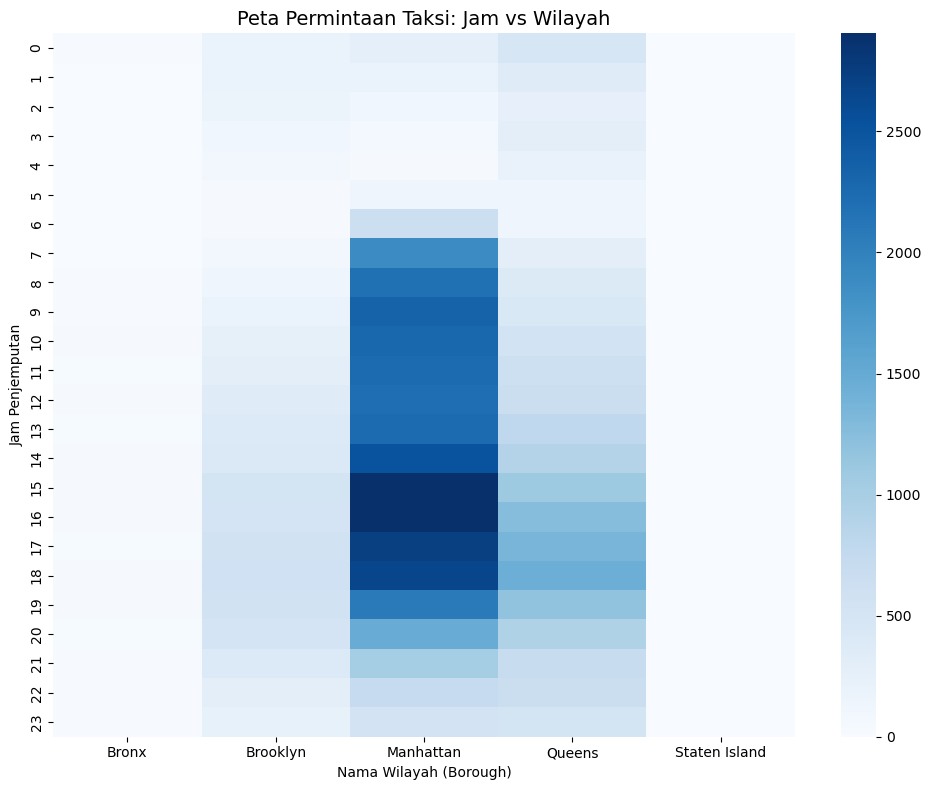

In [102]:
tabel_heatmap = pd.crosstab(df['pickup_hour'], df[df['pickup_borough'] != 'Unknown']['pickup_borough'])

plt.figure(figsize=(10, 8))
sns.heatmap(tabel_heatmap, cmap='Blues', annot=False)
plt.title('Peta Permintaan Taksi: Jam vs Wilayah', fontsize=14)
plt.xlabel('Nama Wilayah (Borough)')
plt.ylabel('Jam Penjemputan')
plt.tight_layout()
plt.show()

**Interpretasi:**  
* Area paling banyak frekuensinya :Manhattan di jam 15:00-19:00 
* Queenskedua paling ramai di jam yang sama  
* Brooklyn Bronx Staten Island flat sepanjang hari  
* semua wilayah sepi di jam 00:00-05:00  

**Implikasi:**
* Manhattan jam 15-19 harus selalu siap armada, bisa di jadikan prioritas   

### 4. Weekday vs Weekend

#### Apakah pola demand di hari kerja berbeda dengan akhir pekan, dan seberapa signifikan?

In [103]:
#juumlah trip per jam yang dipisah berdasarkan tipe harinya wekend atau wekday
trip_jam_tipe = df.groupby(['pickup_hour','tipe_hari']).size().reset_index(name='jumlah_trip')

In [134]:
pivot_jam_tipe = trip_jam_tipe.pivot(index='pickup_hour',columns='tipe_hari',values='jumlah_trip')
pivot_jam_tipe

tipe_hari,Weekday,Weekend
pickup_hour,,
0,501,450
1,328,424
2,206,320
3,197,282
4,136,212
5,222,110
6,720,94
7,2064,203
8,2423,302


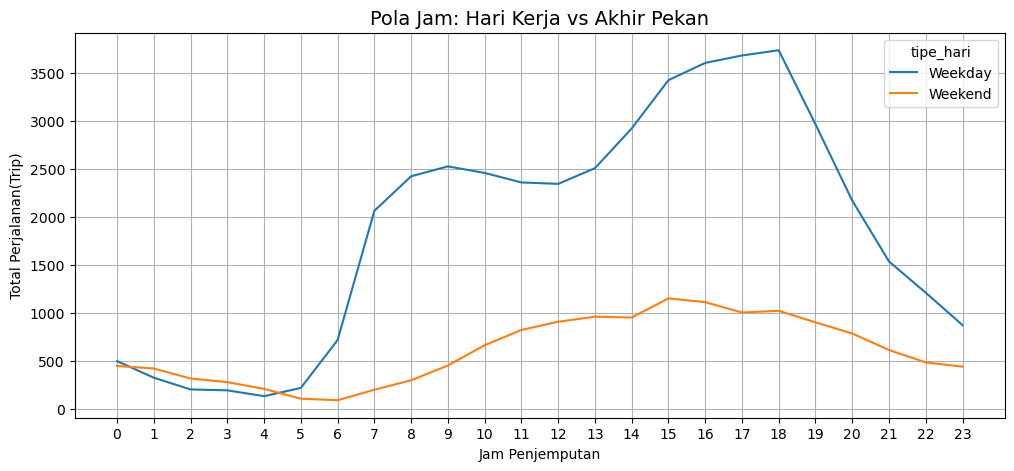

In [127]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=trip_jam_tipe,x='pickup_hour',y='jumlah_trip',hue='tipe_hari')
plt.title('Pola Jam: Hari Kerja vs Akhir Pekan',fontsize=14)
plt.xlabel('Jam Penjemputan')
plt.ylabel('Total Perjalanan(Trip)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [105]:
df['shift_waktu'].value_counts()

shift_waktu
Sore (15-19)         18735
Siang (10-15)        16906
Malam (19-24)        11996
Pagi (06-10)         8787 
Dini Hari (00-05)    3388 
Name: count, dtype: int64

**Insight:**
* Weekday peak di jam 15:00-19:00 sore jam pulang kerja
* Weekend garisnya konsisiten artinya demand tersebar rata dari pagi sampai malam
* Weekend sedikit naik di jam 12:00 dan malam 20:00-22:00, mungkin orang mau berpergian 

uji statistik, apakah benar ada bedanya pola demand di weekend dengan wekdays?

In [106]:
data_weekday = df[df['tipe_hari'] == 'Weekday'].groupby('pickup_date').size()
data_weekend = df[df['tipe_hari'] == 'Weekend'].groupby('pickup_date').size()

In [137]:
#median jumlah trip di weekday dan weekend
median_weekday = data_weekday.median()  
median_weekend = data_weekend.median()  
print(f"Median jumlah trip di weekday: {median_weekday:.2f}")
print(f"Median jumlah trip di weekend: {median_weekend:.2f}")

Median jumlah trip di weekday: 2095.00
Median jumlah trip di weekend: 1570.00


In [136]:
display(data_weekday.head(), data_weekend.head())

pickup_date
2023-01-02    1372
2023-01-03    1856
2023-01-04    2119
2023-01-05    2095
2023-01-06    2243
dtype: int64

pickup_date
2023-01-01    1194
2023-01-07    1904
2023-01-08    1458
2023-01-14    1882
2023-01-15    1555
dtype: int64

In [108]:
stat, p = stats.mannwhitneyu(data_weekday, data_weekend)
print(f"P-Value: {p}")

if p < 0.05:
    print("Tolak H0 (ada perbedaan signifikan demand di weekday dan weekend)")
else:
    print("Gagal tolak H0 (demandnya sama)")

P-Value: 0.001669557787886885
Tolak H0 (ada perbedaan signifikan demand di weekday dan weekend)


berdasarkan hasil uji statistik 2 kelompok terbukti bedaaaa

mencari rata2 atau nilai tengah, apkaah jarak yang ditempuh di weekend sama weekdays beda?

In [109]:
jarak_weekday = df[df['tipe_hari'] == 'Weekday']['trip_distance']
jarak_weekend = df[df['tipe_hari'] == 'Weekend']['trip_distance']

In [110]:
print(jarak_weekday.median())
print(jarak_weekend.median())

1.83
2.02


In [111]:
# Uji MannWhitney: Jarak Tempuh Weekday vs Weekend
stat, p = stats.mannwhitneyu(jarak_weekday, jarak_weekend)
print(f"P-Value: {p}")

if p < 0.05:
    print("Tolak H0")
else:
    print("Gagal Tolak H0")

P-Value: 1.1107158134115396e-26
Tolak H0


**Interpretasi:**
* Trip weekend secara signifikan lebih jauh dari weekday 
* Weekday didominasi perjalanan komuter yang lebih pendek

### 5. Perilaku Penumpang

#### jumlah demand atau perjalanan untuk tipe pesanan (Street-hail vs Dispatch)


In [112]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone', 'durasi_waktu', 'pickup_hour',
       'pickup_day_of_week', 'pickup_day_name', 'pickup_month', 'pickup_date',
       'is_weekend', 'tipe_hari', 'shift_waktu'],
      dtype='object')

In [113]:
tipe_pesan = df.groupby('trip_type').size().reset_index(name='jumlah_trip')
tipe_pesan

,trip_type,jumlah_trip
0,1,59009
1,2,803


In [114]:
map_tipe = {1:'Street-hail', 2:'Dispatch'}
tipe_pesan['trip_type'] = tipe_pesan['trip_type'].map(map_tipe)
tipe_pesan

,trip_type,jumlah_trip
0,Street-hail,59009
1,Dispatch,803


In [115]:
# buat ratatio trip per tipe pesan
tipe_pesan['persentase'] = (tipe_pesan['jumlah_trip']/tipe_pesan['jumlah_trip'].sum())*100
tipe_pesan

,trip_type,jumlah_trip,persentase
0,Street-hail,59009,98.65746
1,Dispatch,803,1.34254


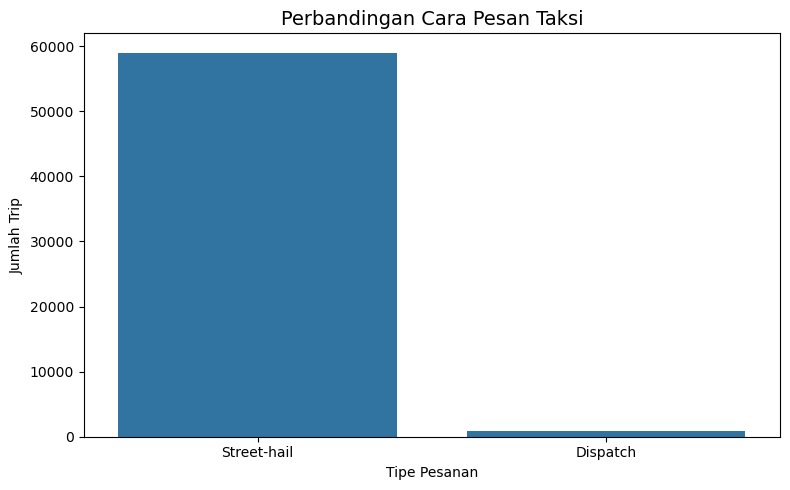

In [116]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tipe_pesan,x='trip_type',y='jumlah_trip')
plt.title('Perbandingan Cara Pesan Taksi', fontsize=14)
plt.xlabel('Tipe Pesanan')
plt.ylabel('Jumlah Trip')
plt.tight_layout()
plt.show()

**interpretasi :**

* sebanyak 98.6% atau 59.009 perjalanan, memesan taksi dengan cara streethail atau memberhentikan armada langsung di pinggir jalan.
* sekitar 1.3% atau 803 perjalanan, memesan taksi dengan pemesanan 

**implikasi**
* dikarenakan pemesanan di dominasi dengan cara memanggil di pinggir jalan, artinya kehadiran fisik armada taxi merupakan hal yang sangat penting, sehingga distribusi armada harus benar2 diperhatikan
* pastikan di setiap wilayah atau zona setiap harak tertentu, taxi bisa terlihat untuk memperbesar peluang terjadinya perjalanan
* mengevaluaasi penyebeb secara berkala kenapa dispatch belum terlalu di manfaatkan pelanggan, apakah pelanggan males menunggu lamanya taxi atau bagaimana

#### Bagaimana rata2 Total Amount atau total pembayan yang dikeluarkan oleh penumpang itu berapa perjam nya?

In [117]:
rata_amount = df.groupby('pickup_hour')['total_amount'].median().reset_index() # pakai median karena data tidak normal dan supaya sebarannya baik
rata_amount.head()

,pickup_hour,total_amount
0,0,16.700
1,1,17.400
2,2,18.300
3,3,18.360
4,4,19.425


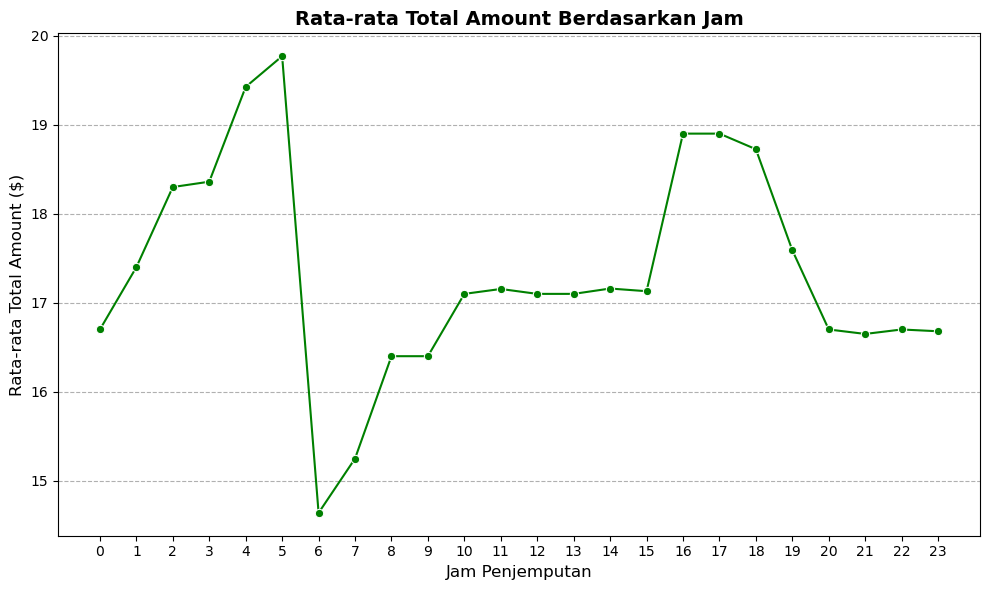

In [118]:
plt.figure(figsize=(10,6))
sns.lineplot(x='pickup_hour', y='total_amount',data=rata_amount,marker='o',color='green')
plt.title('Rata-rata Total Amount Berdasarkan Jam',fontsize=14, fontweight='bold')
plt.xlabel('Jam Penjemputan',fontsize=12)
plt.ylabel('Rata-rata Total Amount ($)',fontsize=12)
plt.xticks(list(df['pickup_hour'].unique()))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**interpretasi :**  

terdapat interpretasi yang menarik, ternyata jika kita bandingkan grafiknya dengan demand taxi per jam pada pertanyaan 1. maka kita melihat kebalikannya ya   
ternyata dengan jumlah perjalanan/ demand yang paling sepi, malah justru menghasilkan rata2 total amount yang lebih ttinggi dibandingkan dengan jam kerja.

mungkin ini di pengaruhi oleh pola konsumen, bisa jadi perjalanan penumpang pada dinihari mayoritas untuk perjalanan jarak jauh. 

#### Bagaimana Rata-rata Jarak Tempuh Berdasarkan Pembagian Waktu

In [119]:
rata_jarak = df.groupby('shift_waktu')['trip_distance'].median().reset_index() # pakai median karena data tidak normal dan supaya sebarannya baik
rata_jarak.head()

C:\Users\merah\AppData\Local\Temp\ipykernel_51528\3851467516.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_jarak = df.groupby('shift_waktu')['trip_distance'].median().reset_index() # pakai median karena data tidak normal dan supaya sebarannya baik


,shift_waktu,trip_distance
0,Dini Hari (00-05),2.25
1,Pagi (06-10),1.77
2,Siang (10-15),1.95
3,Sore (15-19),1.83
4,Malam (19-24),1.85


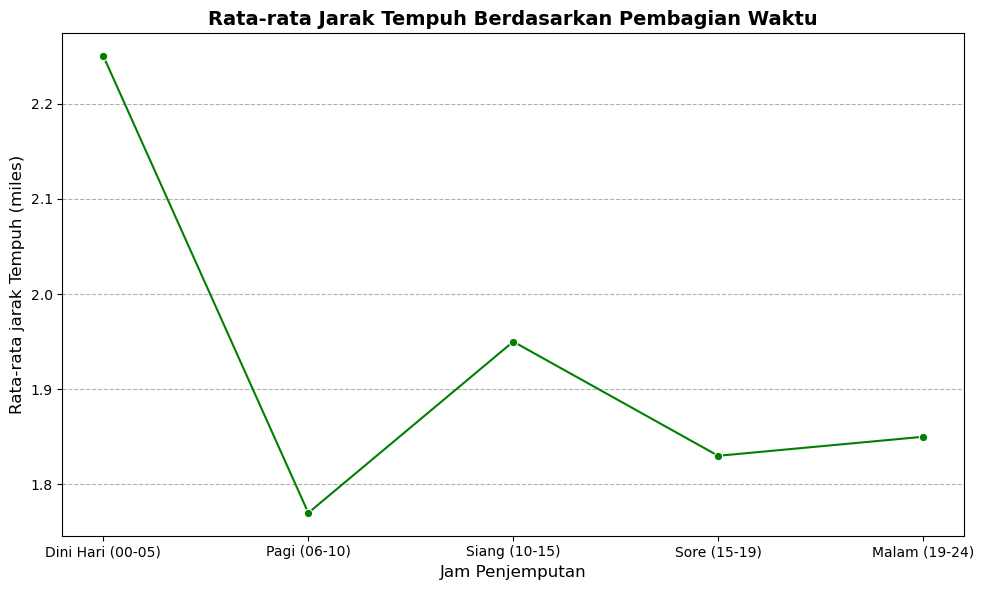

In [120]:
plt.figure(figsize=(10,6))
sns.lineplot(data=rata_jarak,x='shift_waktu', y='trip_distance',marker='o',color='green')
plt.title('Rata-rata Jarak Tempuh Berdasarkan Pembagian Waktu',fontsize=14, fontweight='bold')
plt.xlabel('Jam Penjemputan',fontsize=12)
plt.ylabel('Rata-rata jarak Tempuh (miles)',fontsize=12)
#plt.xticks(list(df['pickup_hour'].unique()))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [121]:
#cari median jarak tempuh per perjalanan
median_jarakm = df['trip_distance'].mean()
median_jarakm

np.float64(2.6436743462850267)

In [122]:
#cari median jarak tempuh per perjalanan
median_jarak = df['trip_distance'].median()
median_jarak

1.88

In [123]:
# median fare amount per perjalanan
median_fare = df['fare_amount'].median()
median_fare

12.8

## **Kesimpulan & Rekomendasi**

### Kesimpulan

1. Pola Waktu 
  * Peak Kesibukan: terjadi pada shift Sore (15:00–19:00) dengan total 18.735 perjalanan, di jam 18:00 (4.758 perjalanan). Sebaliknya, jam 05:00 pagi adalah paling sepi
  * Pola waktu ini menunjukkan bahwa penggunaan sangat didorong oleh mobilitas jam kerja. Hal ini juga didukung oleh uji korelasi Spearman dan Ks yang mengonfirmasi perbedaan jumlah trip antar shift waktu signifikan secara statistik

2. Pola Spasial

  * Meskipun didesain untuk outer boroughs, Manhattan menjadi utama dengan 60,9% dari total trip, jauh di atas Queens (26,2%) dan Brooklyn (11,9%)
  * Zona Emas: Jika dibedah per wilayah, East Harlem North (12.635 trip) dan East Harlem South (8.584 trip) adalah dua zona paling sibuk. Keduanya secara gabungan menyumbang hampir 35% dari keseluruhan pangsa pasar Green Taxi

3. Jam Berapa dan Di Mana?

  * Berdasarkan heatmap antra waktu dan lokasi, hotspot berada di Manhattan pada rentang 15:00 - 19:00  
  * Queens tersibuk kedua pada rentang jam yang sama, tapi intensitasnya seperti manhattan
  * Wilayah Brooklyn, Bronx, dan Staten island = permintaan datar sepanjang hari
  * Semua wilayah sepi pada dini hari (00:00–05:00)

4. Perbandingan Weekday vs Weekend

  * Uji statistik Mann-Whitney membuktikan perbedaan demand yang signifikan (p < 0.05) antara hari kerja dan akhir pekan.
  * Grafik weekday memiliki lonjakan tajam di jam pulang kerja (15:00–19:00), weekend memiliki pola yang merata dari siang sampe malam hari
  * perjalanan di akhir pekan lebih jauh (median 2.02 mil) dibandingkan hari kerja (median 1.83 mil)
  * weekday didominasi komuter jarak pendek, weekend digunakan untuk bepergian yang jauh. 

5. Perilaku Penumpang

  * Pesanan dari pinggir jalan (Street-hail): sebesar 98,6% (59.009 perjalanan)
  * Hanya kecil (1,3% atau 803 perjalanan) yang menggunakan sistem pemesanan (dispatch).
  * anomali Dini Hari (Tarif Tertinggi): Jam operasional dengan demand paling sepi menghasilkan rata-rata total pembayaran paling tinggi, $20 per perjalanan. diatas dari jam-jam sibuk
  * Shift Dini Hari (00:00–05:00) memiliki median jarak perjalanan terjauh (2,25 mil) dibandingkan shift waktu lainnya
  * Kesimpulan: penumpang di jam sibuk didominasi oleh komuter jarak pendek, sedangkan penumpang di jam sepi (dini hari) adalah orang yang melakukan perjalanan jarak jauh

### Rekomendasi Operasional

1. Prioritaskan armada taxi di area dan jam sibuk   
* terkkhusus di East Harlem pada pukul 15:00–19:00. Karena 98,6% penumpang menyetop langsung di jalan (street-hail), taksi wajib kelihatan fisiknya di jam pulang kerja.

2. Strategi Dini Hari: Sedikit tapi "Cuan"   
* Kurangi armada di jam 00:00–05:00 pagi untuk efisiensi biaya oprasional,
* Namun, bisa juga alokasikan armada di bbrapa lokasi tertentu, krena penumpang dini hari punya jarak tempuh dan tarif paling tinggi

3. Weekday vs weekend 
* Weekday: Main cepat dan kuantitas karena untuk melayani rute komuter jarak pendek di sekitar Manhattan
* Weekend: Sebarkan armada lebih luas ke wilayah luar karena penumpang lebih banyak untuk bepergian jarak jauh

4. Promosi untuk Dispatch  
*Pemesanan via panggilan/aplikasi hanya 1,3%. Tingkatkan promosi dispatch, supaya supir ga perlu keliling mencari penumpang di area yang sepi orang nyetop di jalan

In [152]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'rate_code_id',
       'pickup_location_id', 'dropoff_location_id', 'passenger_count',
       'trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
       'payment_type', 'trip_type', 'pickup_borough', 'pickup_zone',
       'dropoff_borough', 'dropoff_zone', 'durasi_waktu', 'pickup_hour',
       'pickup_day_of_week', 'pickup_day_name', 'pickup_month', 'pickup_date',
       'is_weekend', 'tipe_hari', 'shift_waktu'],
      dtype='object')